In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import os

import sys
sys.path.append("./libraries")
import cloud_processing_lib as cpl
import compare_plots as cplt

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

In [2]:
### get days to analyze

start_date = dt.datetime(2026, 1, 23)
end_date = dt.datetime(2026, 7, 1)

days_n = (end_date-start_date).days

days_to_read = []
cur_date = start_date

for i in range(0, days_n):
    days_to_read.append(cur_date)
    cur_date += dt.timedelta(days=1)

In [3]:
# read DIY ASI data (max theta 80)

dataframe_collector = []

for day in days_to_read:
    read_path = "/home/sdoeding/analysis_scripts/retrieval_outfiles/out_{0:04d}{1:02d}{2:02d}.csv".format(day.year, day.month, day.day)
    if os.path.isfile(read_path):
        dataframe_collector.append(pd.read_csv(read_path, delimiter=";"))

data_diy_80 = pd.concat(dataframe_collector)
data_diy_80["Timestamp"] = pd.to_datetime(data_diy_80["Timestamp"])#.astype('datetime64[ns]')
correction_mask = data_diy_80["Timestamp"].dt.second.isin([1,31])
data_diy_80.loc[correction_mask, "Timestamp"] = data_diy_80.loc[correction_mask, "Timestamp"] - pd.Timedelta(seconds=1)
data_diy_80.set_index("Timestamp", inplace=True)
data_diy_80.drop(columns=["Unnamed: 0"], inplace=True)

data_diy_80.replace(-1, np.nan, inplace=True)

,RB_Fraction,BRBG_Fraction
Timestamp,,
2026-01-23 05:30:00,NaN,NaN
2026-01-23 06:30:00,NaN,NaN
2026-01-23 06:31:00,NaN,NaN
2026-01-23 06:31:30,NaN,NaN
2026-01-23 06:51:00,NaN,NaN
...,...,...
2026-06-30 20:06:00,NaN,NaN
2026-06-30 20:30:00,NaN,NaN
2026-06-30 21:30:00,NaN,NaN


In [4]:
# read DIY ASI data (max theta 65)

dataframe_collector = []

for day in days_to_read:
    read_path = "/home/sdoeding/analysis_scripts/comm_compare_outfiles/out_{0:04d}{1:02d}{2:02d}.csv".format(day.year, day.month, day.day)
    if os.path.isfile(read_path):
        dataframe_collector.append(pd.read_csv(read_path, delimiter=";"))

data_diy_65 = pd.concat(dataframe_collector)
data_diy_65["Timestamp"] = pd.to_datetime(data_diy_65["Timestamp"])#.astype('datetime64[ns]')
correction_mask = data_diy_65["Timestamp"].dt.second.isin([1,31])
data_diy_65.loc[correction_mask, "Timestamp"] = data_diy_65.loc[correction_mask, "Timestamp"] - pd.Timedelta(seconds=1)
data_diy_65.set_index("Timestamp", inplace=True)
data_diy_65.drop(columns=["Unnamed: 0"], inplace=True)

data_diy_65.replace(-1, np.nan, inplace=True)

,RB_Fraction,BRBG_Fraction
Timestamp,,
2026-01-23 05:30:00,NaN,NaN
2026-01-23 06:30:00,NaN,NaN
2026-01-23 06:31:00,NaN,NaN
2026-01-23 06:31:30,NaN,NaN
2026-01-23 06:51:00,NaN,NaN
...,...,...
2026-06-30 20:06:00,NaN,NaN
2026-06-30 20:30:00,NaN,NaN
2026-06-30 21:30:00,NaN,NaN


In [5]:
# read DIY ASI data (max theta 5)

dataframe_collector = []

for day in days_to_read:
    read_path = "/home/sdoeding/analysis_scripts/retrieval_pencil/out_{0:04d}{1:02d}{2:02d}.csv".format(day.year, day.month, day.day)
    if os.path.isfile(read_path):
        dataframe_collector.append(pd.read_csv(read_path, delimiter=";"))

data_diy_05 = pd.concat(dataframe_collector)
data_diy_05["Timestamp"] = pd.to_datetime(data_diy_05["Timestamp"])#.astype('datetime64[ns]')
correction_mask = data_diy_05["Timestamp"].dt.second.isin([1,31])
data_diy_05.loc[correction_mask, "Timestamp"] = data_diy_05.loc[correction_mask, "Timestamp"] - pd.Timedelta(seconds=1)
data_diy_05.set_index("Timestamp", inplace=True)
data_diy_05.drop(columns=["Unnamed: 0"], inplace=True)

data_diy_05.replace(-1, np.nan, inplace=True)

,RB_Fraction,BRBG_Fraction
Timestamp,,
2026-01-23 05:30:00,NaN,NaN
2026-01-23 06:30:00,NaN,NaN
2026-01-23 06:31:00,NaN,NaN
2026-01-23 06:31:30,NaN,NaN
2026-01-23 06:51:00,NaN,NaN
...,...,...
2026-06-30 20:06:00,NaN,NaN
2026-06-30 20:30:00,NaN,NaN
2026-06-30 21:30:00,NaN,NaN


In [6]:
# read COMM ASI data

data_com = pd.read_csv("./auxiliary/comm_out.csv", delimiter=";")
data_com.columns = ["Filename", "Cloudiness", "Sun_Azimuth", "Sun_Elevation"]

data_com["Timestamp"] = pd.to_datetime(data_com["Filename"], format="%Y%m%d%H%M%S_11.jpg")
data_com.set_index("Timestamp", inplace=True)
data_com.sort_values("Timestamp", axis=0, inplace=True)
data_com.drop(columns=["Filename"], inplace=True)
data_com["Cloudiness"] = data_com["Cloudiness"] * 100

In [7]:
# read CEI data (ceilometer)

dataframe_collector = []

for day in days_to_read:
    read_path = "/home/sdoeding/analysis_scripts/ceilo_outfiles/ceilo_out_{0:04d}{1:02d}{2:02d}.csv".format(day.year, day.month, day.day)
    if os.path.isfile(read_path):
        dataframe_collector.append(pd.read_csv(read_path))

data_cei = pd.concat(dataframe_collector)

data_cei["time"] = pd.to_datetime(data_cei["time"])
data_cei.rename(columns={"time":"Timestamp"}, inplace=True)
data_cei.set_index("Timestamp", inplace=True)

In [8]:
# read CEI data (ceilometer) bothsided

dataframe_collector = []

for day in days_to_read:
    read_path = "/home/sdoeding/analysis_scripts/ceilo_outfiles_bothsided/ceilo_out_{0:04d}{1:02d}{2:02d}.csv".format(day.year, day.month, day.day)
    if os.path.isfile(read_path):
        dataframe_collector.append(pd.read_csv(read_path))

data_cei_sym = pd.concat(dataframe_collector)

data_cei_sym["time"] = pd.to_datetime(data_cei_sym["time"])#.astype('datetime64[ns]')
# correction_mask = data_diy_65["Timestamp"].dt.second.isin([1,31])
# data_diy_65.loc[correction_mask, "Timestamp"] = data_diy_65.loc[correction_mask, "Timestamp"] - pd.Timedelta(seconds=1)
data_cei_sym.rename(columns={"time":"Timestamp"}, inplace=True)
data_cei_sym.set_index("Timestamp", inplace=True)

In [9]:
# ceilo resample to 30sec interval from imagers
data_cei_res = data_cei.resample("30s", label="right").mean()
data_cei_sym_res = data_cei_sym.resample("30s", label="right").mean()

In [10]:
#### MERGE ALL DATASETS

data_cei_res.rename(columns={"tcc_empi":"ceilo_own_left", "tcc_auto":"ceilo_auto"}, inplace=True)

data_cei_sym_res.rename(columns={"tcc_empi":"ceilo_own_symm"}, inplace=True)
data_cei_sym_res.drop(columns=["tcc_auto"], inplace=True)

data_com.rename(columns={"Cloudiness":"comm"}, inplace=True)

data_diy_05.rename(columns={"RB_Fraction": "diy_05_rb", "BRBG_Fraction":"diy_05_brbg"}, inplace=True)

data_diy_65.rename(columns={"RB_Fraction": "diy_65_rb", "BRBG_Fraction":"diy_65_brbg"}, inplace=True)

data_diy_80.rename(columns={"RB_Fraction": "diy_80_rb", "BRBG_Fraction":"diy_80_brbg"}, inplace=True)


df_complete = data_cei_res.merge(data_cei_sym_res, how="outer", left_index=True, right_index=True)
df_complete = df_complete.merge(data_com, how="outer", left_index=True, right_index=True)
df_complete = df_complete.merge(data_diy_05, how="outer", left_index=True, right_index=True)
df_complete = df_complete.merge(data_diy_65, how="outer", left_index=True, right_index=True)
df_complete = df_complete.merge(data_diy_80, how="outer", left_index=True, right_index=True)


df_complete_10min = df_complete.resample("60min", label="right").mean().round()

df_complete

,ceilo_auto,ceilo_own_left,ceilo_own_symm,int_time,comm,Sun_Azimuth,Sun_Elevation,diy_05_rb,diy_05_brbg,diy_65_rb,diy_65_brbg,diy_80_rb,diy_80_brbg
Timestamp,,,,,,,,,,,,,
2026-01-23 00:00:30,12.5,0.0,0.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-23 00:01:00,12.5,0.0,0.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-23 00:01:30,12.5,0.0,0.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-23 00:02:00,12.5,0.0,0.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-23 00:02:30,12.5,0.0,0.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-30 20:06:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-30 20:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-30 21:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


93487


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 66.2 % --- 1 octa: 82.3%
RMSE [octa]: 1.3892331959312967


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:48: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 70.7 % --- 1 octa: 79.6%
RMSE [%]: 17.627316035694932


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:17: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)
/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


RMSE [%]: 17.627316035694932
Exact: 69.3 % --- 1 octa: 88.8%
RMSE [octa]: 0.9845686472671953
Exact: 67.4 % --- 1 octa: 89.4%
RMSE [octa]: 1.003619621791973


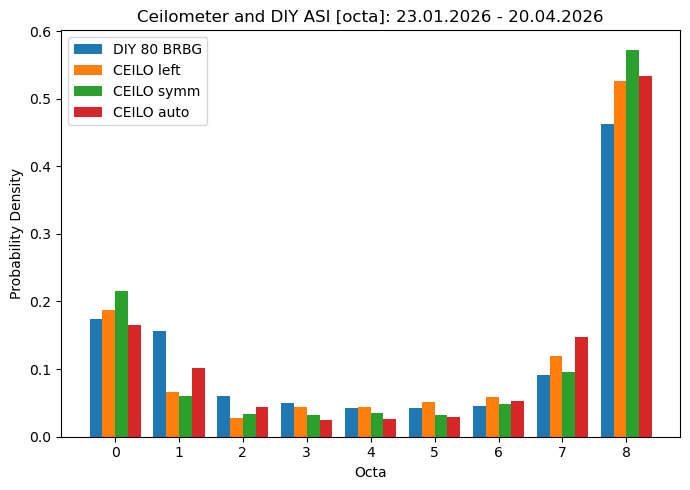

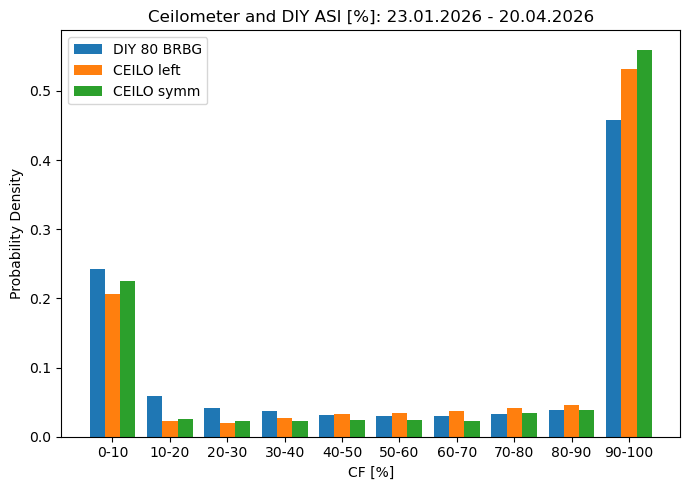

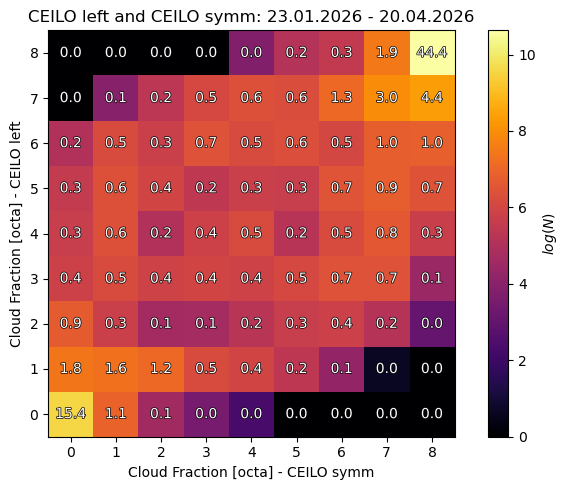

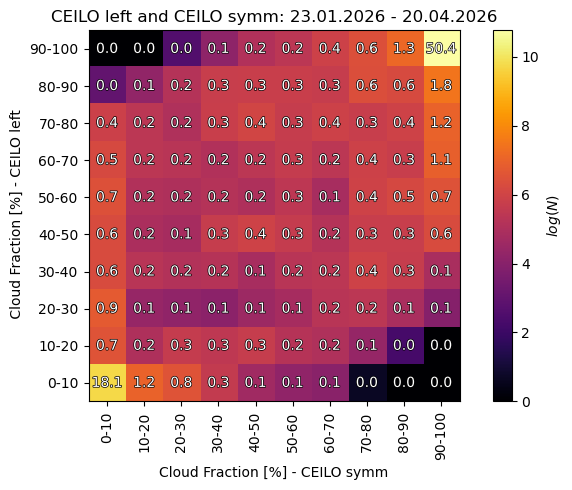

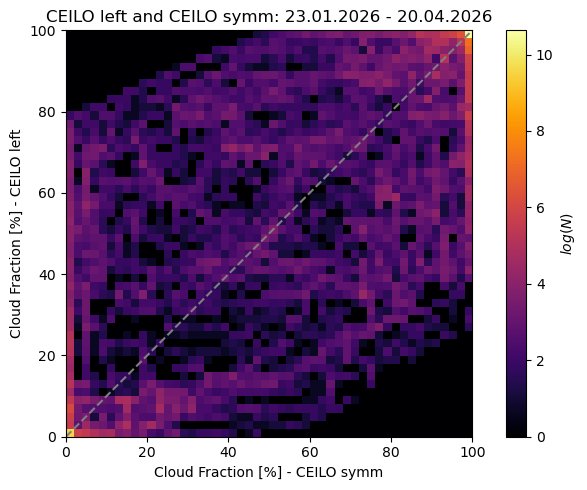

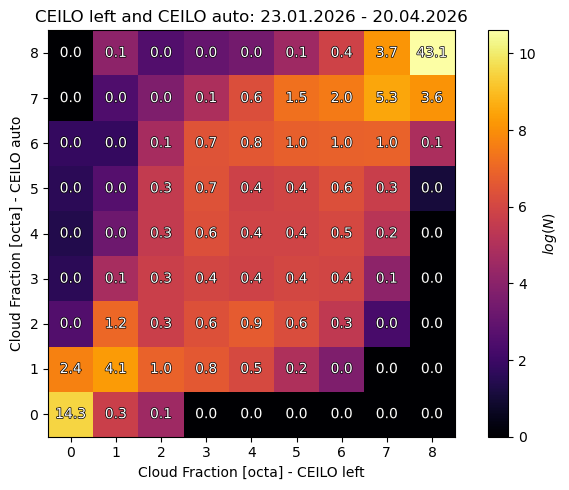

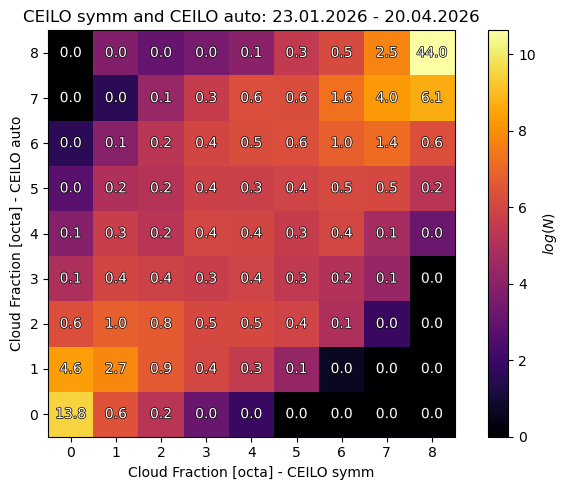

In [13]:
#01-03# COMPARISON: Ceilometer all methods

df_select = df_complete[["ceilo_own_left", "ceilo_own_symm", "ceilo_auto", "diy_80_brbg"]]
df_select.dropna(inplace=True)

print(len(df_select))

df_select_octa = df_select.copy()

df_select_octa["ceilo_own_left"] = cpl.convert_frac_to_octa(df_select_octa["ceilo_own_left"])
df_select_octa["ceilo_own_symm"] = cpl.convert_frac_to_octa(df_select_octa["ceilo_own_symm"])
df_select_octa["ceilo_auto"] = cpl.convert_frac_to_octa(df_select_octa["ceilo_auto"])
df_select_octa["diy_80_brbg"] = cpl.convert_frac_to_octa(df_select_octa["diy_80_brbg"])

####################################

hist_collector = [df_select_octa["diy_80_brbg"], df_select_octa["ceilo_own_left"], df_select_octa["ceilo_own_symm"], df_select_octa["ceilo_auto"]]
label_collector = ["DIY 80 BRBG", "CEILO left","CEILO symm","CEILO auto"]

cplt.render_n_col_octa(hist_collector, label_collector,"Ceilometer and DIY ASI [octa]: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
                  "compare_ceilo_all_cols.png")

####################################

hist_collector = [df_select["diy_80_brbg"], df_select["ceilo_own_left"], df_select["ceilo_own_symm"]]
label_collector = ["DIY 80 BRBG", "CEILO left","CEILO symm"]

cplt.render_n_col_frac(hist_collector, label_collector,"Ceilometer and DIY ASI [%]: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
                  "compare_ceilo_all_co10.png")

####################################

plot_txy = ["CEILO left and CEILO symm: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [octa] - CEILO symm", "Cloud Fraction [octa] - CEILO left"]

cplt.render_heatmap_octa(df_select_octa["ceilo_own_symm"], df_select_octa["ceilo_own_left"], plot_txy, "compare_ceiloownsymm_ceiloownleft_octa.png")

####################################

plot_txy = ["CEILO left and CEILO symm: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - CEILO symm", " Cloud Fraction [%] - CEILO left"]

cplt.render_heatmap_frac10(df_select["ceilo_own_symm"], df_select["ceilo_own_left"], plot_txy, "compare_ceiloownsymm_ceiloownleft_fr10.png")

####################################

plot_txy = ["CEILO left and CEILO symm: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - CEILO symm", "Cloud Fraction [%] - CEILO left"]

cplt.render_heatmap_frac(df_select["ceilo_own_symm"], df_select["ceilo_own_left"], plot_txy, "compare_ceiloownsymm_ceiloownleft_frac.png")


####################################

plot_txy = ["CEILO left and CEILO auto: {0} - {1}".format(data_cei_res.index[0].strftime("%d.%m.%Y"),data_cei_res.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [octa] - CEILO left", "Cloud Fraction [octa] - CEILO auto"]

cplt.render_heatmap_octa(df_select_octa["ceilo_own_left"], df_select_octa["ceilo_auto"], plot_txy, "compare_ceiloownleft_ceiloauto_octa.png")

####################################

plot_txy = ["CEILO symm and CEILO auto: {0} - {1}".format(data_cei_res.index[0].strftime("%d.%m.%Y"),data_cei_res.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [octa] - CEILO symm", "Cloud Fraction [octa] - CEILO auto"]

cplt.render_heatmap_octa(df_select_octa["ceilo_own_symm"], df_select_octa["ceilo_auto"], plot_txy, "compare_ceiloownsymm_ceiloauto_octa.png")


93487
RMSE [%]: 28.012205506512952


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:17: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 60.1 % --- 1 octa: 71.0%
RMSE [%]: 28.012205506512952


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 51.2 % --- 1 octa: 73.7%
RMSE [octa]: 2.2188159893077612


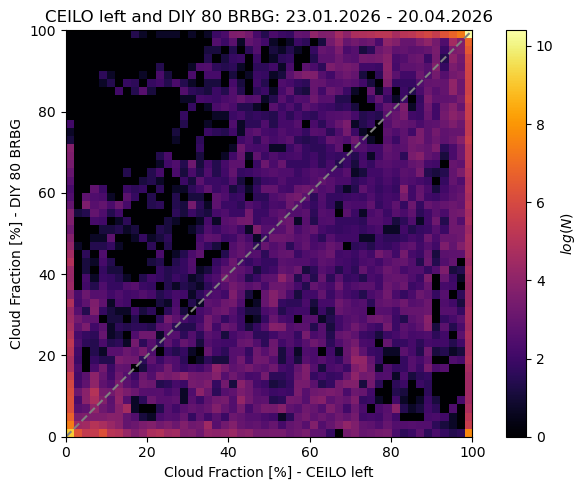

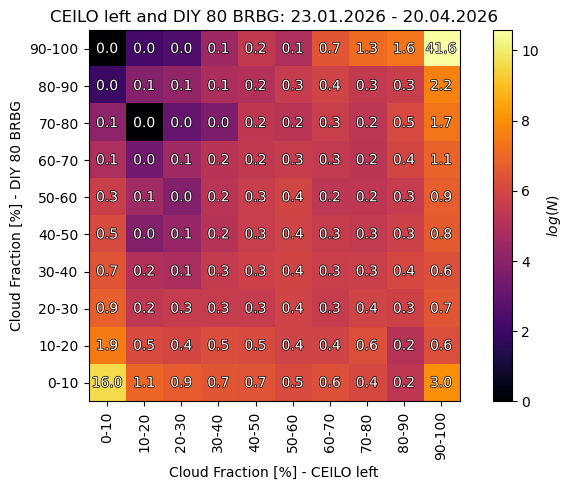

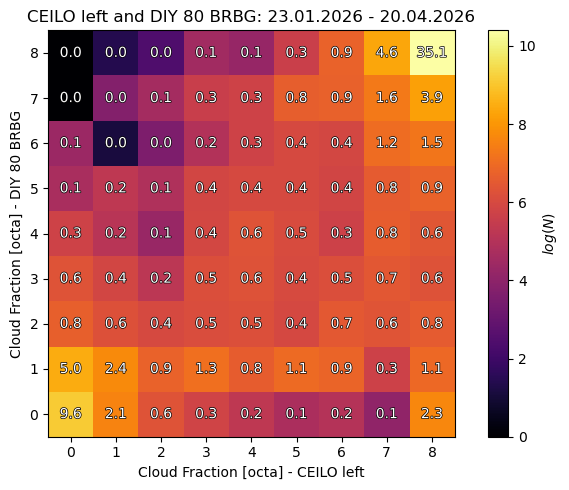

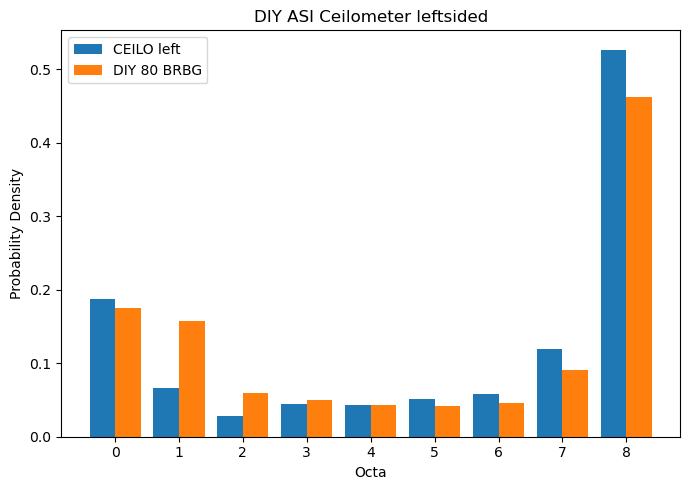

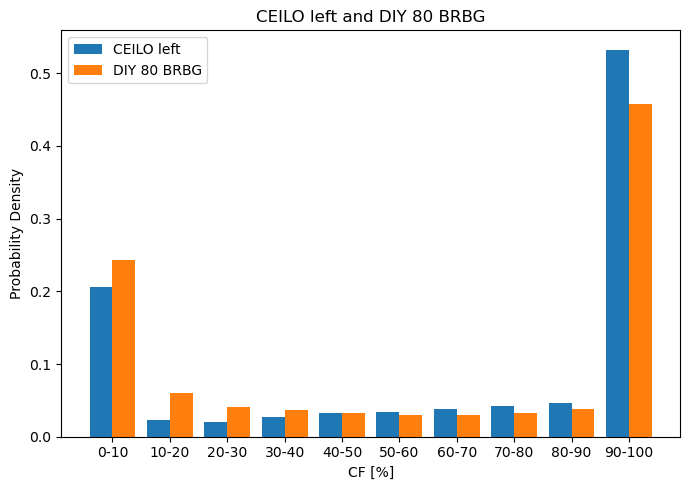

In [15]:
#38# COMPARISON: DIY ASI 80 (BRBG) - CEILO own left

df_select = df_complete[["ceilo_own_left", "diy_80_brbg"]]
df_select.dropna(inplace=True)

print(len(df_select))

nameroot = "compare_ceiloownleft_diy80brbg"

#######################################################################################################################################

plot_txy=["CEILO left and DIY 80 BRBG: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
         "Cloud Fraction [%] - CEILO left", "Cloud Fraction [%] - DIY 80 BRBG"]

cplt.render_heatmap_frac(df_select["ceilo_own_left"], df_select["diy_80_brbg"], plot_txy, nameroot+"_frac.png")

#######################################################################################################################################

plot_txy = ["CEILO left and DIY 80 BRBG: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - CEILO left", "Cloud Fraction [%] - DIY 80 BRBG"]

cplt.render_heatmap_frac10(df_select["ceilo_own_left"], df_select["diy_80_brbg"], plot_txy, nameroot+"_fr10.png")


#######################################################################################################################################

df_select_octa = df_select.copy()

df_select_octa["diy_80_brbg"] = cpl.convert_frac_to_octa(df_select_octa["diy_80_brbg"])
df_select_octa["ceilo_own_left"] = cpl.convert_frac_to_octa(df_select_octa["ceilo_own_left"])

plot_txy = ["CEILO left and DIY 80 BRBG: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [octa] - CEILO left", "Cloud Fraction [octa] - DIY 80 BRBG"]

cplt.render_heatmap_octa(df_select_octa["ceilo_own_left"], df_select_octa["diy_80_brbg"], plot_txy, nameroot+"_octa.png")

#######################################################################################################################################

hist_collector = [df_select_octa["ceilo_own_left"], df_select_octa["diy_80_brbg"]]
label_collector = ["CEILO left", "DIY 80 BRBG"]

cplt.render_n_col_octa(hist_collector, label_collector, "DIY ASI Ceilometer leftsided", nameroot+"_cols.png")

#######################################################################################################################################

hist_collector = [df_select["ceilo_own_left"], df_select["diy_80_brbg"]]
label_collector = ["CEILO left", "DIY 80 BRBG"]

cplt.render_n_col_frac(hist_collector, label_collector, "CEILO left and DIY 80 BRBG", nameroot+"_co10.png")

93487
RMSE [%]: 27.663258049682877
Exact: 62.2 % --- 1 octa: 73.7%
RMSE [%]: 27.663258049682877


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 53.5 % --- 1 octa: 75.7%
RMSE [octa]: 2.1908594710529727


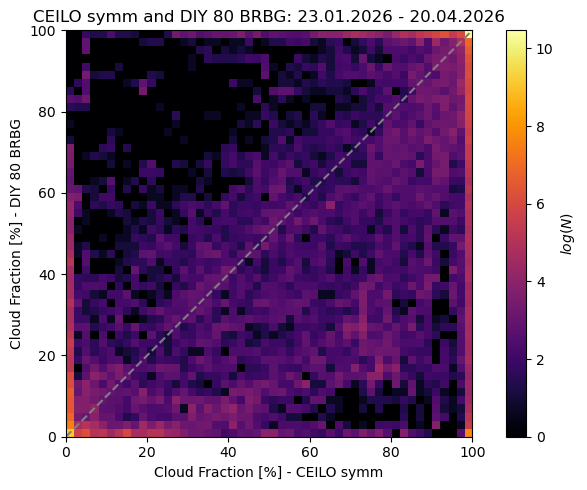

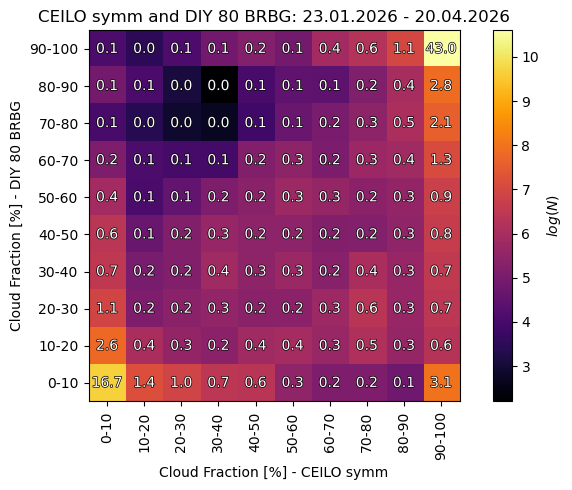

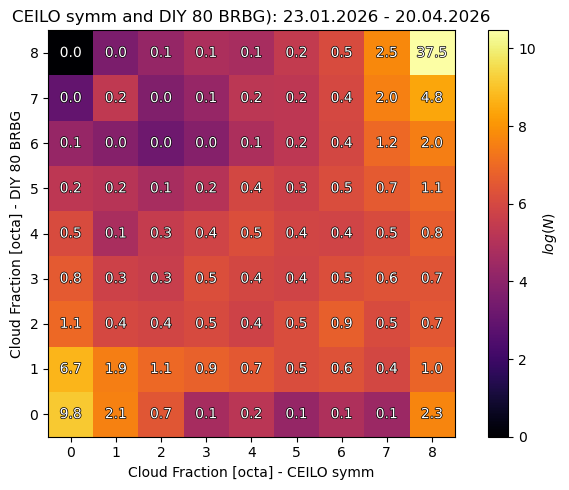

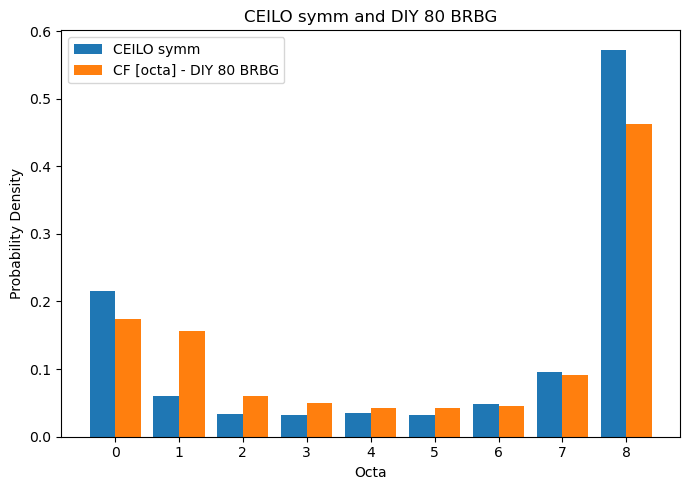

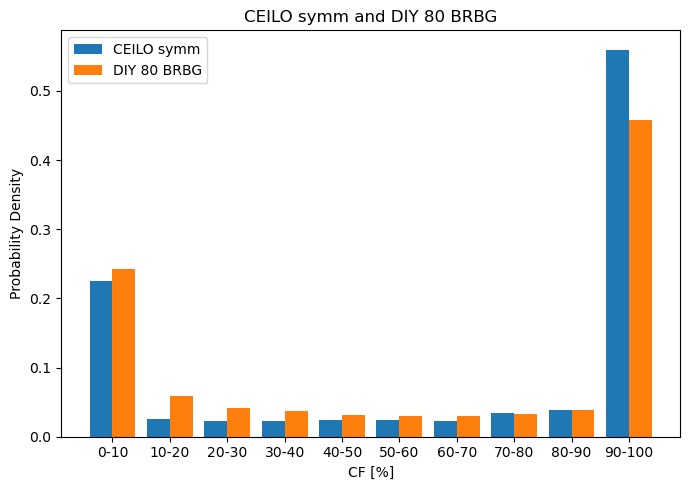

In [14]:
#39# COMPARISON: DIY ASI 80 (BRBG) - CEILO symmetrical

df_select = df_complete[["ceilo_own_symm", "diy_80_brbg"]]
df_select.dropna(inplace=True)

print(len(df_select))

nameroot = "compare_ceiloownsymm_diy80brbg"

#######################################################################################################################################

plot_txy=["CEILO symm and DIY 80 BRBG: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
         "Cloud Fraction [%] - CEILO symm", "Cloud Fraction [%] - DIY 80 BRBG"]

cplt.render_heatmap_frac(df_select["ceilo_own_symm"], df_select["diy_80_brbg"], plot_txy, nameroot+"_frac.png")

#######################################################################################################################################

plot_txy = ["CEILO symm and DIY 80 BRBG: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - CEILO symm", "Cloud Fraction [%] - DIY 80 BRBG"]

cplt.render_heatmap_frac10(df_select["ceilo_own_symm"], df_select["diy_80_brbg"], plot_txy, nameroot+"_fr10.png")

#######################################################################################################################################

df_select_octa = df_select.copy()

df_select_octa["diy_80_brbg"] = cpl.convert_frac_to_octa(df_select["diy_80_brbg"])
df_select_octa["ceilo_own_symm"] = cpl.convert_frac_to_octa(df_select["ceilo_own_symm"])

plot_txy = ["CEILO symm and DIY 80 BRBG): {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [octa] - CEILO symm", "Cloud Fraction [octa] - DIY 80 BRBG"]

cplt.render_heatmap_octa(df_select_octa["ceilo_own_symm"], df_select_octa["diy_80_brbg"], plot_txy, nameroot+"_octa.png")

#######################################################################################################################################

hist_collector = [df_select_octa["ceilo_own_symm"], df_select_octa["diy_80_brbg"]]
label_collector = ["CEILO symm", "CF [octa] - DIY 80 BRBG"]

cplt.render_n_col_octa(hist_collector, label_collector, "CEILO symm and DIY 80 BRBG", nameroot+"_cols.png")

#######################################################################################################################################

hist_collector = [df_select["ceilo_own_symm"], df_select["diy_80_brbg"]]
label_collector = ["CEILO symm", "DIY 80 BRBG"]

cplt.render_n_col_frac(hist_collector, label_collector, "CEILO symm and DIY 80 BRBG", nameroot+"_co10.png")

93487
Exact: 51.6 % --- 1 octa: 76.8%
RMSE [octa]: 2.1511597601952333


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


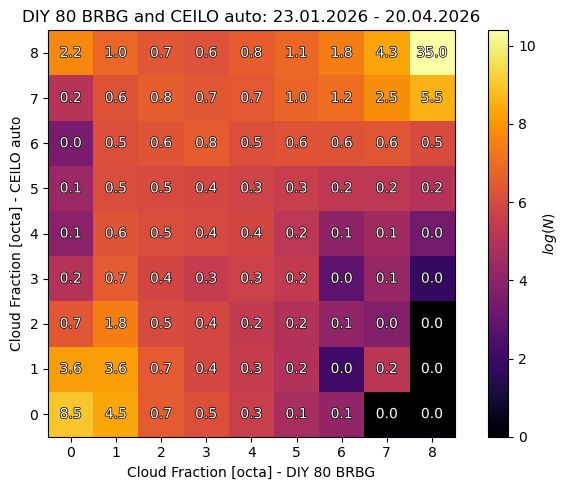

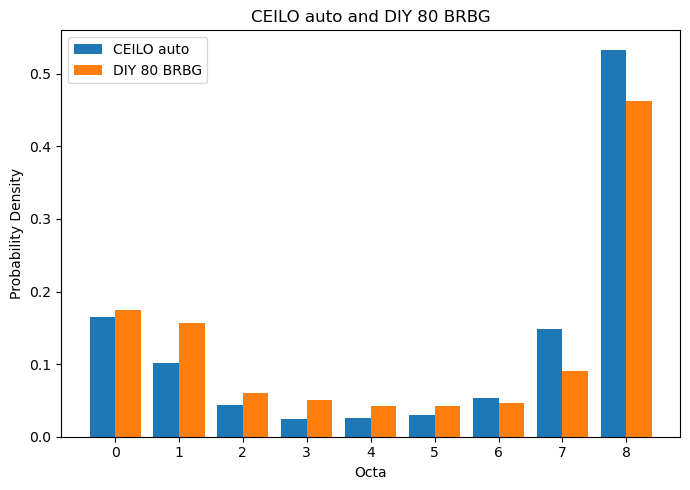

In [16]:
#37# COMPARISON: DIY ASI 80 (BRBG) - CEILO auto

df_select = df_complete[["ceilo_auto", "diy_80_brbg"]]
df_select.dropna(inplace=True)

print(len(df_select))

nameroot = "compare_ceiloauto_diy80brbg"

#######################################################################################################################################

df_select_octa = df_select.copy()

df_select_octa["diy_80_brbg"] = cpl.convert_frac_to_octa(df_select["diy_80_brbg"])
df_select_octa["ceilo_auto"] = cpl.convert_frac_to_octa(df_select["ceilo_auto"])

plot_txy = ["DIY 80 BRBG and CEILO auto: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [octa] - DIY 80 BRBG", "Cloud Fraction [octa] - CEILO auto"]

cplt.render_heatmap_octa(df_select_octa["diy_80_brbg"], df_select_octa["ceilo_auto"], plot_txy, nameroot+"_octa.png")

#######################################################################################################################################

hist_collector = [df_select_octa["ceilo_auto"], df_select_octa["diy_80_brbg"]]
label_collector = ["CEILO auto", "DIY 80 BRBG"]

cplt.render_n_col_octa(hist_collector, label_collector, "CEILO auto and DIY 80 BRBG", nameroot+"_cols.png")

90957
RMSE [%]: 16.71087634121974


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:17: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)
/home/sdoeding/analysis_scripts/libraries/compare_plots.py:48: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 64.1 % --- 1 octa: 83.6%
RMSE [%]: 16.71087634121974


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 57.6 % --- 1 octa: 86.7%
RMSE [octa]: 1.3421340105998472


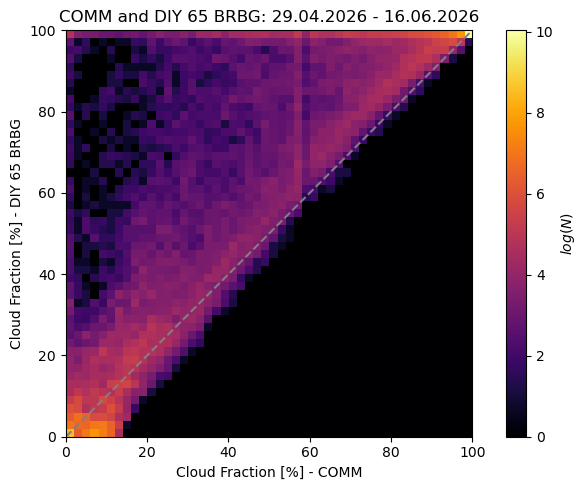

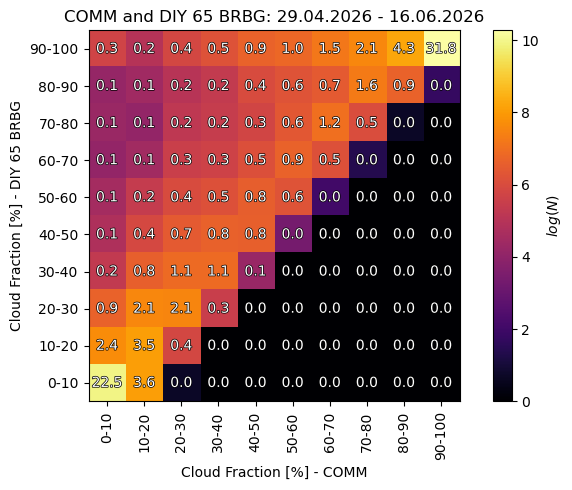

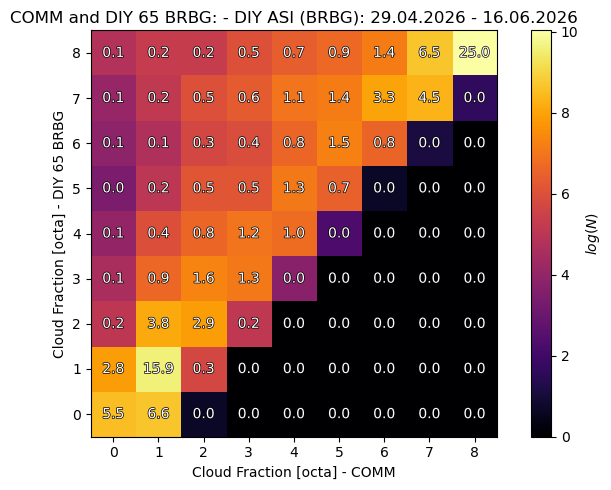

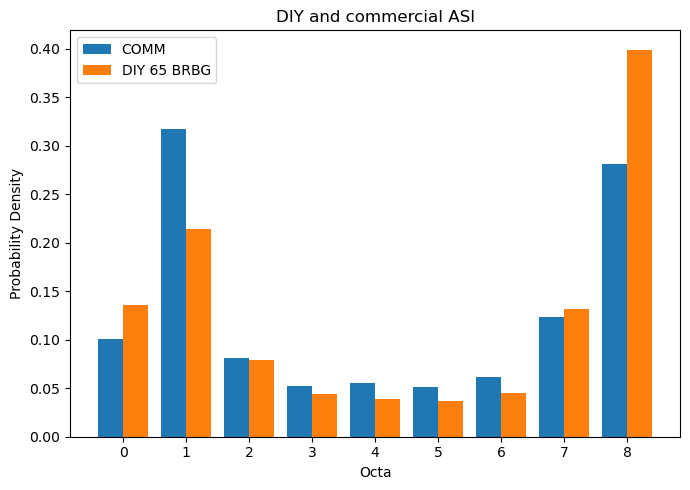

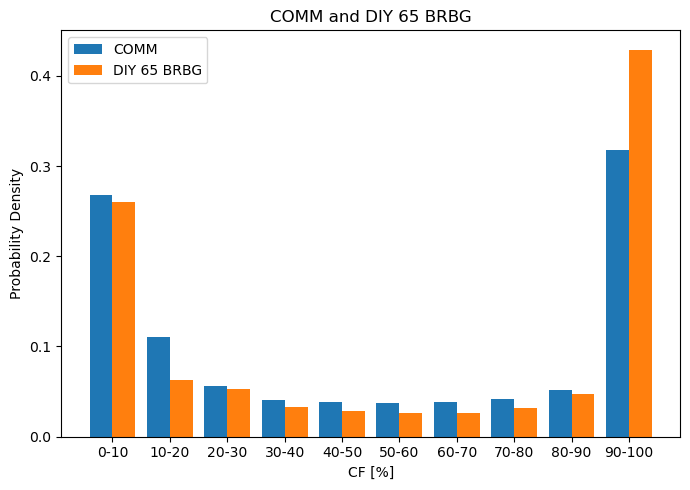

In [12]:
#25# COMPARISON: DIY ASI 65 (BRBG) - COMM

df_select = df_complete[["comm", "diy_65_brbg"]]
df_select.dropna(inplace=True)

print(len(df_select))

nameroot = "compare_comm_diy65brbg"

#######################################################################################################################################

plot_txy = ["COMM and DIY 65 BRBG: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - COMM", "Cloud Fraction [%] - DIY 65 BRBG"]

cplt.render_heatmap_frac(df_select["comm"], df_select["diy_65_brbg"], plot_txy, nameroot+"_frac.png")

#######################################################################################################################################

plot_txy = ["COMM and DIY 65 BRBG: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - COMM", "Cloud Fraction [%] - DIY 65 BRBG"]

cplt.render_heatmap_frac10(df_select["comm"], df_select["diy_65_brbg"], plot_txy, nameroot+"_fr10.png")

#######################################################################################################################################

df_select_octa = df_select.copy()

df_select_octa["diy_65_brbg"] = cpl.convert_frac_to_octa(df_select_octa["diy_65_brbg"])
df_select_octa["comm"] = cpl.convert_frac_to_octa(df_select_octa["comm"])

plot_txy=["COMM and DIY 65 BRBG: - DIY ASI (BRBG): {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
         "Cloud Fraction [octa] - COMM", "Cloud Fraction [octa] - DIY 65 BRBG"]

cplt.render_heatmap_octa(df_select_octa["comm"], df_select_octa["diy_65_brbg"], plot_txy, nameroot+"_octa.png")

#######################################################################################################################################

hist_collector = [df_select_octa["comm"], df_select_octa["diy_65_brbg"]]
label_collector = ["COMM", "DIY 65 BRBG"]

cplt.render_n_col_octa(hist_collector, label_collector, "DIY and commercial ASI", nameroot+"_cols.png")

#######################################################################################################################################

hist_collector = [df_select["comm"], df_select["diy_65_brbg"]]
label_collector = ["COMM", "DIY 65 BRBG"]

cplt.render_n_col_frac(hist_collector, label_collector, "COMM and DIY 65 BRBG", nameroot+"_co10.png")

90957
RMSE [%]: 21.082845505920584


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:17: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)
/home/sdoeding/analysis_scripts/libraries/compare_plots.py:48: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 51.8 % --- 1 octa: 72.2%
RMSE [%]: 21.082845505920584


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 40.7 % --- 1 octa: 76.9%
RMSE [octa]: 1.6646425035819812


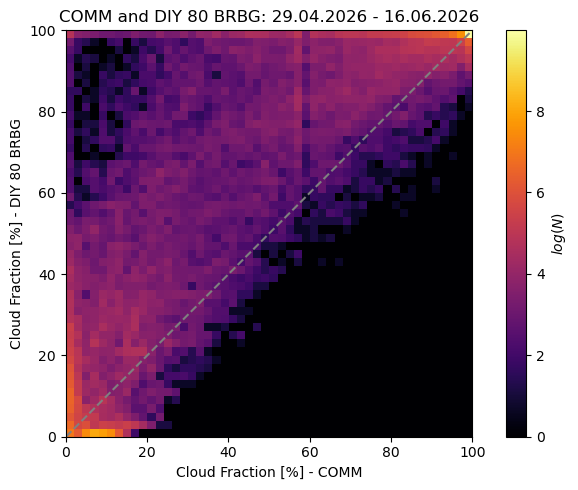

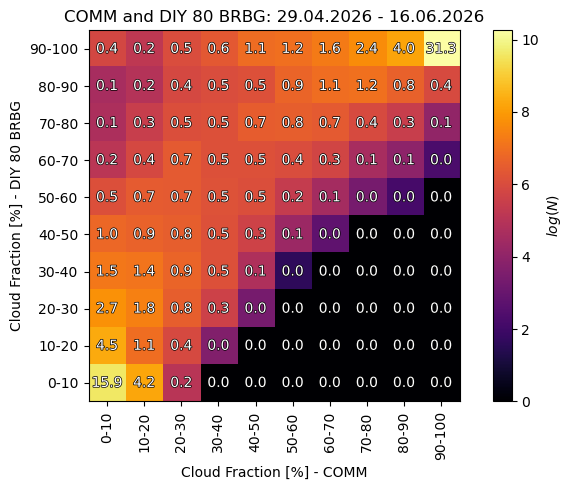

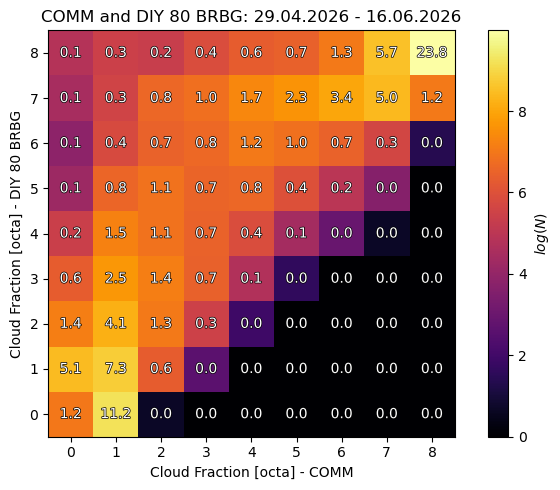

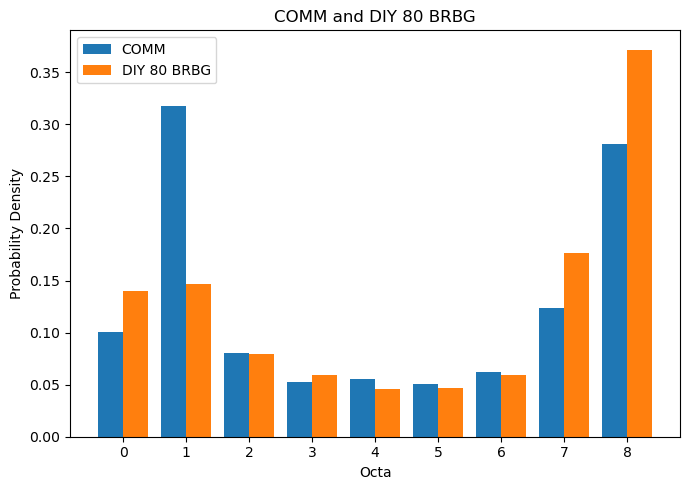

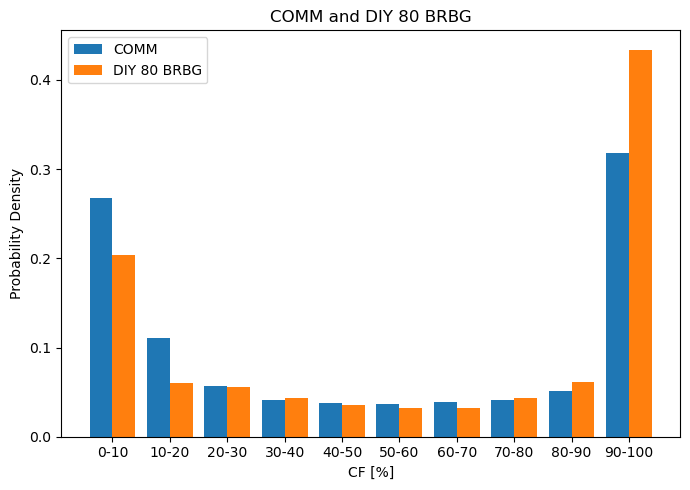

In [17]:
#40# COMPARISON: DIY ASI 80 (BRBG) - COMM

df_select = df_complete[["comm", "diy_80_brbg"]]
df_select.dropna(inplace=True)

print(len(df_select))

nameroot = "compare_comm_diy80brbg"

#######################################################################################################################################

plot_txy = ["COMM and DIY 80 BRBG: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - COMM", "Cloud Fraction [%] - DIY 80 BRBG"]

cplt.render_heatmap_frac(df_select["comm"], df_select["diy_80_brbg"], plot_txy, nameroot+"_frac.png")

#######################################################################################################################################

plot_txy = ["COMM and DIY 80 BRBG: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - COMM", "Cloud Fraction [%] - DIY 80 BRBG"]

cplt.render_heatmap_frac10(df_select["comm"], df_select["diy_80_brbg"], plot_txy, nameroot+"_fr10.png")

#######################################################################################################################################

df_select_octa = df_select.copy()

df_select_octa["diy_80_brbg"] = cpl.convert_frac_to_octa(df_select_octa["diy_80_brbg"])
df_select_octa["comm"] = cpl.convert_frac_to_octa(df_select_octa["comm"])

plot_txy=["COMM and DIY 80 BRBG: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
         "Cloud Fraction [octa] - COMM", "Cloud Fraction [octa] - DIY 80 BRBG"]

cplt.render_heatmap_octa(df_select_octa["comm"], df_select_octa["diy_80_brbg"], plot_txy, nameroot+"_octa.png")

#######################################################################################################################################

hist_collector = [df_select_octa["comm"], df_select_octa["diy_80_brbg"]]
label_collector = ["COMM", "DIY 80 BRBG"]

cplt.render_n_col_octa(hist_collector, label_collector, "COMM and DIY 80 BRBG", nameroot+"_cols.png")

#######################################################################################################################################

hist_collector = [df_select["comm"], df_select["diy_80_brbg"]]
label_collector = ["COMM", "DIY 80 BRBG"]

cplt.render_n_col_frac(hist_collector, label_collector, "COMM and DIY 80 BRBG", nameroot+"_co10.png")

236905
RMSE [%]: 10.17029987979815


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:17: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)
/home/sdoeding/analysis_scripts/libraries/compare_plots.py:48: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 66.1 % --- 1 octa: 87.0%
RMSE [%]: 10.17029987979815


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 61.4 % --- 1 octa: 92.0%
RMSE [octa]: 0.8459333903453659


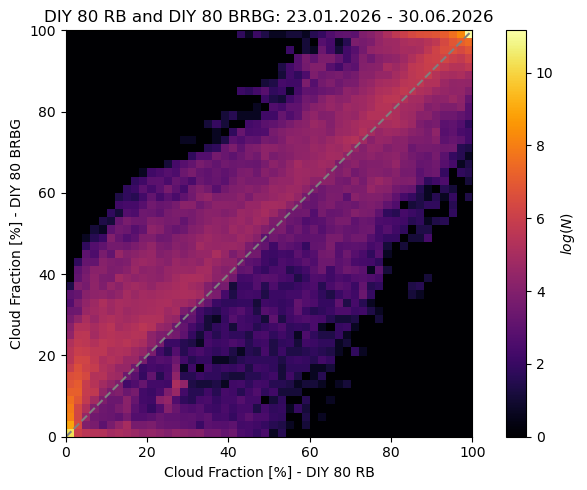

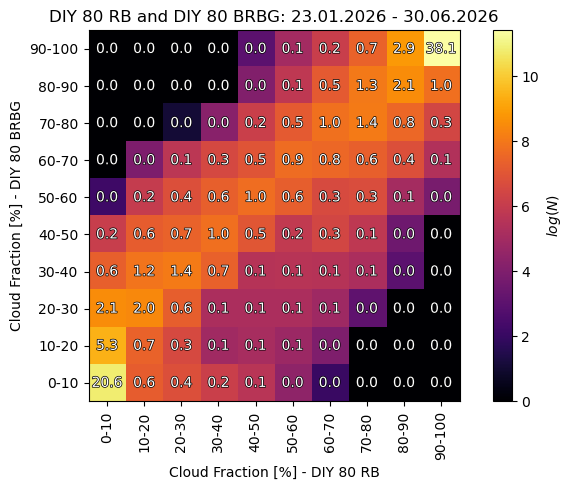

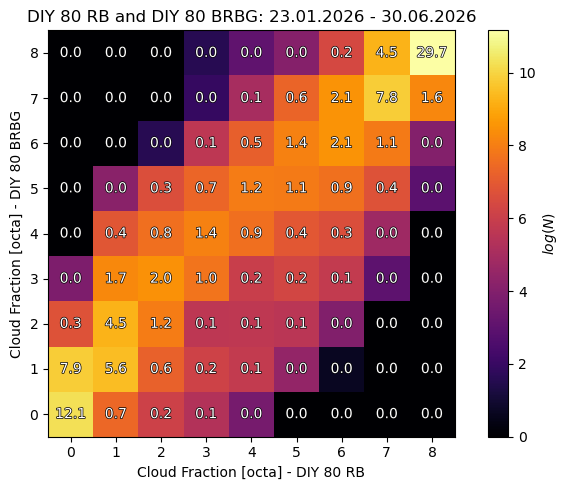

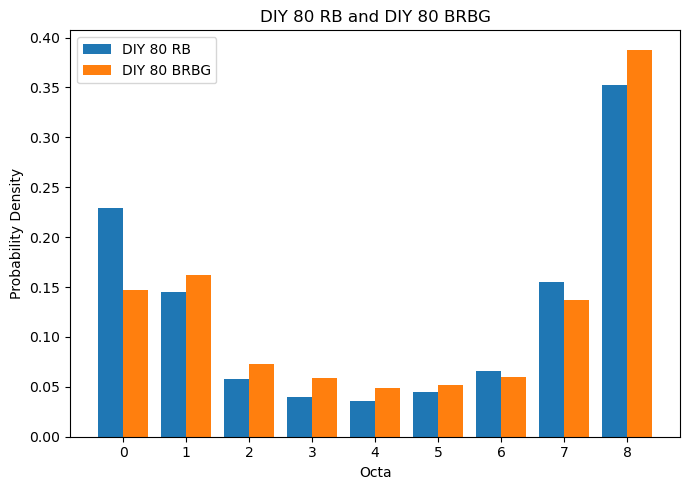

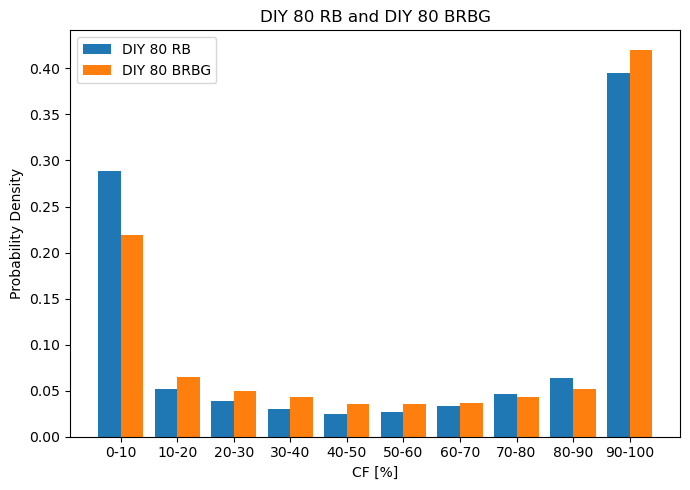

In [11]:
#45# COMPARISON: DIY ASI 80 (BRBG) - DIY ASI 80 (RB)

df_select = df_complete[["diy_80_rb", "diy_80_brbg"]]
df_select.dropna(inplace=True)

print(len(df_select))

nameroot = "compare_diy80rb_diy80brbg"

#######################################################################################################################################

plot_txy = ["DIY 80 RB and DIY 80 BRBG: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - DIY 80 RB", "Cloud Fraction [%] - DIY 80 BRBG"]

cplt.render_heatmap_frac(df_select["diy_80_rb"], df_select["diy_80_brbg"], plot_txy, nameroot+"_frac.png")

#######################################################################################################################################

plot_txy = ["DIY 80 RB and DIY 80 BRBG: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - DIY 80 RB", "Cloud Fraction [%] - DIY 80 BRBG"]

cplt.render_heatmap_frac10(df_select["diy_80_rb"], df_select["diy_80_brbg"], plot_txy, nameroot+"_fr10.png")

#######################################################################################################################################

df_select_octa = df_select.copy()

df_select_octa["diy_80_brbg"] = cpl.convert_frac_to_octa(df_select_octa["diy_80_brbg"])
df_select_octa["diy_80_rb"] = cpl.convert_frac_to_octa(df_select_octa["diy_80_rb"])

plot_txy = ["DIY 80 RB and DIY 80 BRBG: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [octa] - DIY 80 RB", "Cloud Fraction [octa] - DIY 80 BRBG"]

cplt.render_heatmap_octa(df_select_octa["diy_80_rb"], df_select_octa["diy_80_brbg"], plot_txy, nameroot+"_octa.png")

#######################################################################################################################################

hist_collector = [df_select_octa["diy_80_rb"], df_select_octa["diy_80_brbg"]]
label_collector = ["DIY 80 RB", "DIY 80 BRBG"]

cplt.render_n_col_octa(hist_collector, label_collector, "DIY 80 RB and DIY 80 BRBG", nameroot+"_cols.png")

#######################################################################################################################################

hist_collector = [df_select["diy_80_rb"], df_select["diy_80_brbg"]]
label_collector = ["DIY 80 RB", "DIY 80 BRBG"]

cplt.render_n_col_frac(hist_collector, label_collector, "DIY 80 RB and DIY 80 BRBG", nameroot+"_co10.png")

93487
Exact: 50.0 % --- 1 octa: 74.8%
RMSE [octa]: 2.166376534232251


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


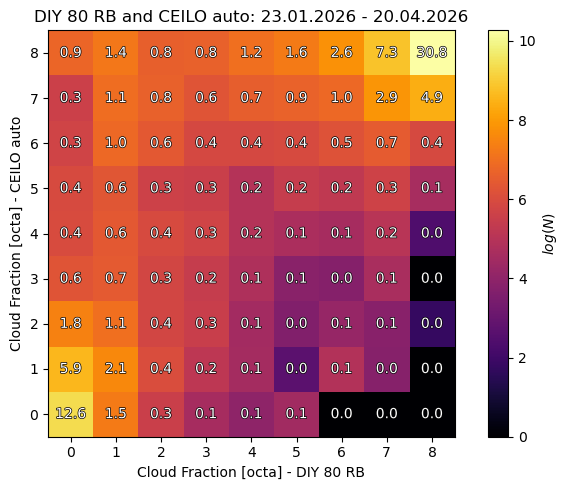

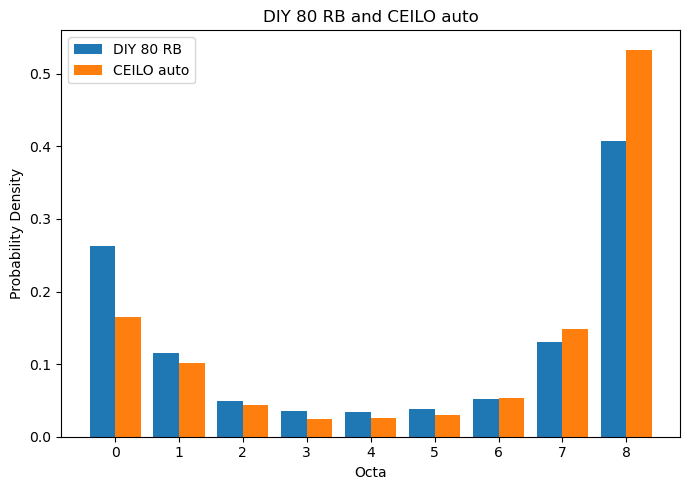

In [18]:
#29# COMPARISON: DIY ASI 80 (RB) - CEILO auto

df_select = df_complete[["diy_80_rb", "ceilo_auto"]]
df_select.dropna(inplace=True)

print(len(df_select))

nameroot = "compare_diy80rb_ceiloauto"

df_select_octa = df_select.copy()

df_select_octa["ceilo_auto"] = cpl.convert_frac_to_octa(df_select_octa["ceilo_auto"])
df_select_octa["diy_80_rb"] = cpl.convert_frac_to_octa(df_select_octa["diy_80_rb"])

plot_txy = ["DIY 80 RB and CEILO auto: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [octa] - DIY 80 RB", "Cloud Fraction [octa] - CEILO auto"]

cplt.render_heatmap_octa(df_select_octa["diy_80_rb"], df_select_octa["ceilo_auto"], plot_txy, nameroot+"_octa.png")

#######################################################################################################################################

hist_collector = [df_select_octa["diy_80_rb"], df_select_octa["ceilo_auto"]]
label_collector = ["DIY 80 RB", "CEILO auto"]

cplt.render_n_col_octa(hist_collector, label_collector, "DIY 80 RB and CEILO auto", nameroot+"_cols.png")

93487
RMSE [%]: 28.43712679370175


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:17: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)
/home/sdoeding/analysis_scripts/libraries/compare_plots.py:48: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 59.9 % --- 1 octa: 70.2%
RMSE [%]: 28.43712679370175


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 50.0 % --- 1 octa: 72.1%
RMSE [octa]: 2.2405863989808177


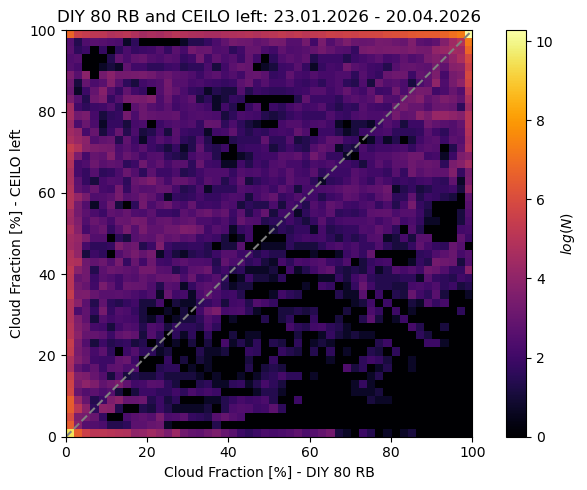

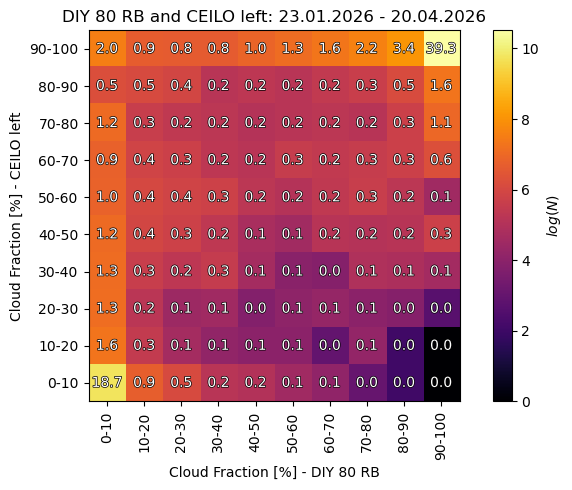

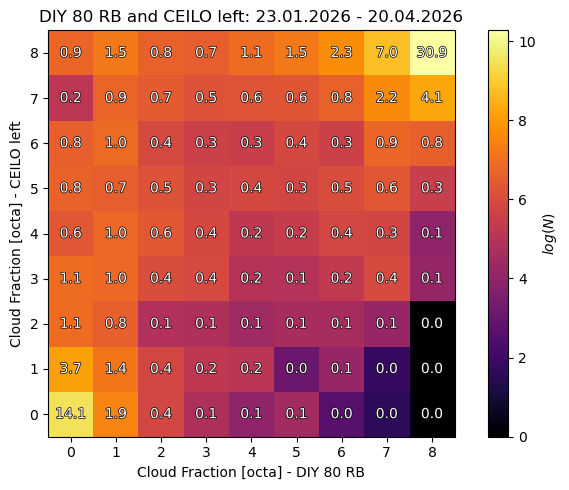

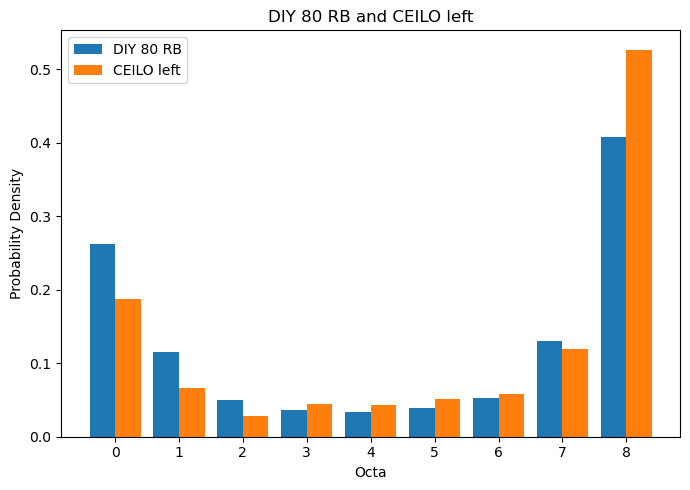

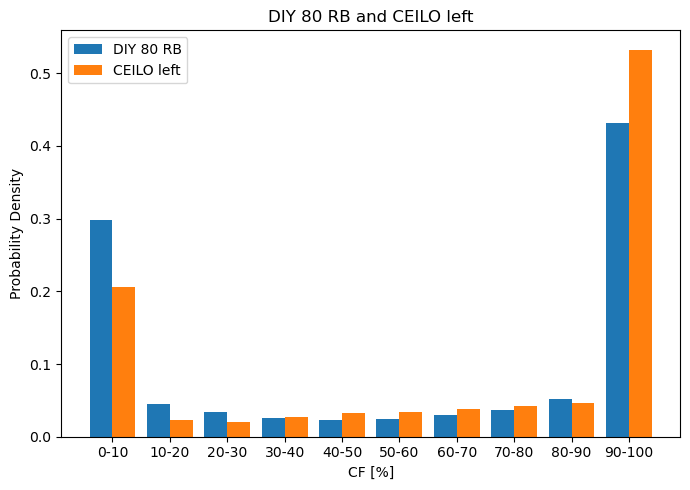

In [19]:
#30# COMPARISON: DIY ASI 80 (RB) - CEILO own left

df_select = df_complete[["diy_80_rb", "ceilo_own_left"]]
df_select.dropna(inplace=True)

print(len(df_select))

nameroot = "compare_diy80rb_ceiloownleft"

#######################################################################################################################################

plot_txy = ["DIY 80 RB and CEILO left: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - DIY 80 RB", "Cloud Fraction [%] - CEILO left"]

cplt.render_heatmap_frac(df_select["diy_80_rb"], df_select["ceilo_own_left"], plot_txy, nameroot+"_frac.png")

#######################################################################################################################################

plot_txy = ["DIY 80 RB and CEILO left: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - DIY 80 RB", "Cloud Fraction [%] - CEILO left"]

cplt.render_heatmap_frac10(df_select["diy_80_rb"], df_select["ceilo_own_left"], plot_txy, nameroot+"_fr10.png")

#######################################################################################################################################

df_select_octa = df_select.copy()

df_select_octa["diy_80_rb"] = cpl.convert_frac_to_octa(df_select_octa["diy_80_rb"])
df_select_octa["ceilo_own_left"] = cpl.convert_frac_to_octa(df_select_octa["ceilo_own_left"])

plot_txy = ["DIY 80 RB and CEILO left: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [octa] - DIY 80 RB", "Cloud Fraction [octa] - CEILO left"]

cplt.render_heatmap_octa(df_select_octa["diy_80_rb"], df_select_octa["ceilo_own_left"], plot_txy, nameroot+"_octa.png")

#######################################################################################################################################

hist_collector = [df_select_octa["diy_80_rb"], df_select_octa["ceilo_own_left"]]
label_collector = ["DIY 80 RB", "CEILO left"]

cplt.render_n_col_octa(hist_collector, label_collector, "DIY 80 RB and CEILO left", nameroot+"_cols.png")

#######################################################################################################################################

hist_collector = [df_select["diy_80_rb"], df_select["ceilo_own_left"]]
label_collector = ["DIY 80 RB", "CEILO left"]

cplt.render_n_col_frac(hist_collector, label_collector, "DIY 80 RB and CEILO left", nameroot+"_co10.png")

93487
RMSE [%]: 27.664788038017


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:17: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 62.1 % --- 1 octa: 72.9%
RMSE [%]: 27.664788038017


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 53.3 % --- 1 octa: 74.2%
RMSE [octa]: 2.1704831837530274


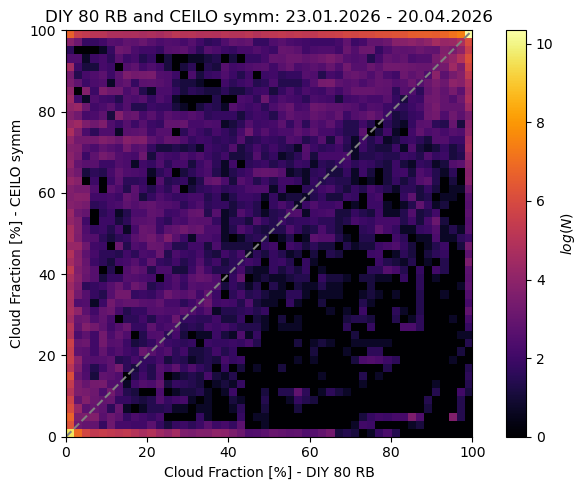

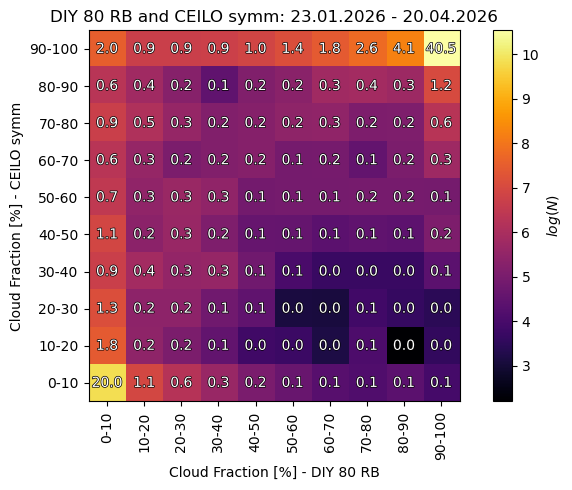

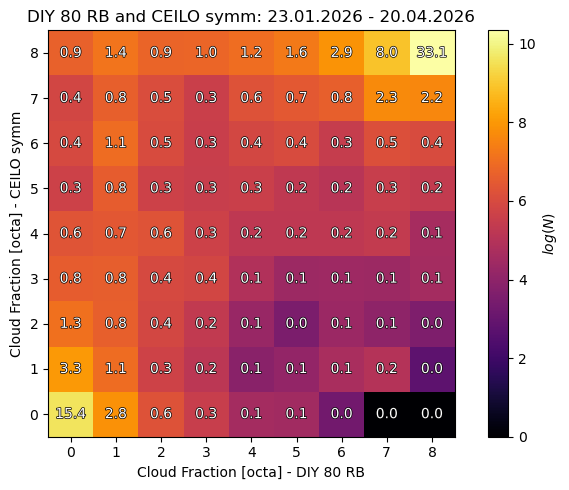

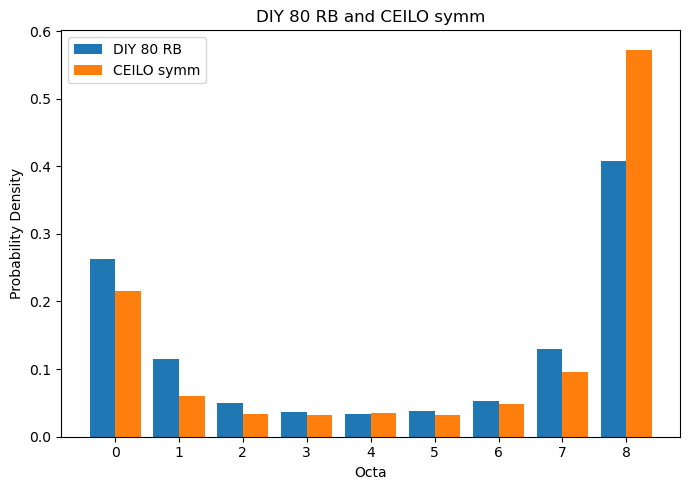

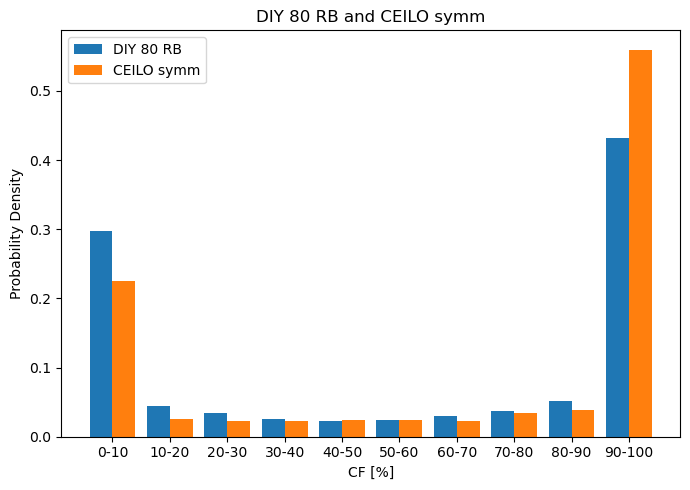

In [20]:
#31# COMPARISON: DIY ASI 80 (RB) - CEILO own symm

df_select = df_complete[["diy_80_rb", "ceilo_own_symm"]]
df_select.dropna(inplace=True)

print(len(df_select))

nameroot = "compare_diy80rb_ceiloownsymm"

#######################################################################################################################################

plot_txy = ["DIY 80 RB and CEILO symm: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - DIY 80 RB", "Cloud Fraction [%] - CEILO symm"]

cplt.render_heatmap_frac(df_select["diy_80_rb"], df_select["ceilo_own_symm"], plot_txy, nameroot+"_frac.png")

#######################################################################################################################################

plot_txy = ["DIY 80 RB and CEILO symm: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - DIY 80 RB", "Cloud Fraction [%] - CEILO symm"]

cplt.render_heatmap_frac10(df_select["diy_80_rb"], df_select["ceilo_own_symm"], plot_txy, nameroot+"_fr10.png")

#######################################################################################################################################

df_select_octa = df_select.copy()

df_select_octa["diy_80_rb"] = cpl.convert_frac_to_octa(df_select_octa["diy_80_rb"])
df_select_octa["ceilo_own_symm"] = cpl.convert_frac_to_octa(df_select_octa["ceilo_own_symm"])

plot_txy = ["DIY 80 RB and CEILO symm: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [octa] - DIY 80 RB", "Cloud Fraction [octa] - CEILO symm"]

cplt.render_heatmap_octa(df_select_octa["diy_80_rb"], df_select_octa["ceilo_own_symm"], plot_txy, nameroot+"_octa.png")

#######################################################################################################################################

hist_collector = [df_select_octa["diy_80_rb"], df_select_octa["ceilo_own_symm"]]
label_collector = ["DIY 80 RB", "CEILO symm"]

cplt.render_n_col_octa(hist_collector, label_collector, "DIY 80 RB and CEILO symm", nameroot+"_cols.png")

#######################################################################################################################################

hist_collector = [df_select["diy_80_rb"], df_select["ceilo_own_symm"]]
label_collector = ["DIY 80 RB", "CEILO symm"]

cplt.render_n_col_frac(hist_collector, label_collector, "DIY 80 RB and CEILO symm", nameroot+"_co10.png")

90957
RMSE [%]: 18.694178172176386


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:17: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)
/home/sdoeding/analysis_scripts/libraries/compare_plots.py:48: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 56.3 % --- 1 octa: 76.9%
RMSE [%]: 18.694178172176386


/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 41.6 % --- 1 octa: 81.1%
RMSE [octa]: 1.5064972471283828


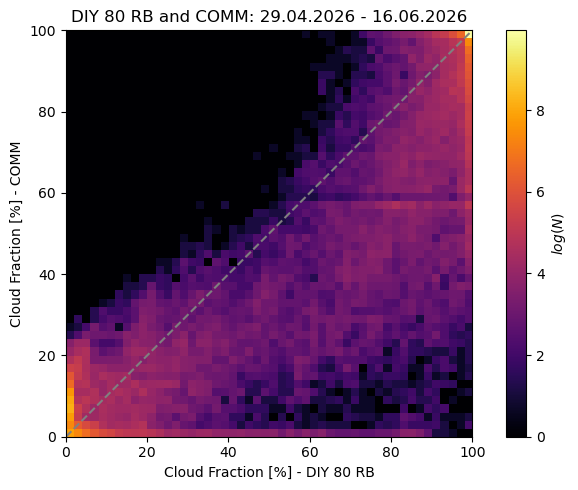

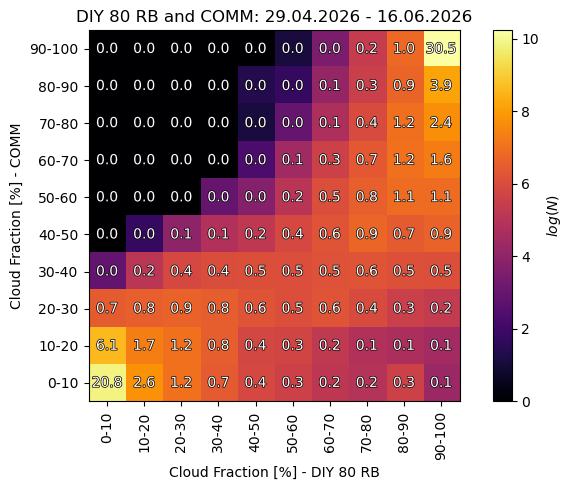

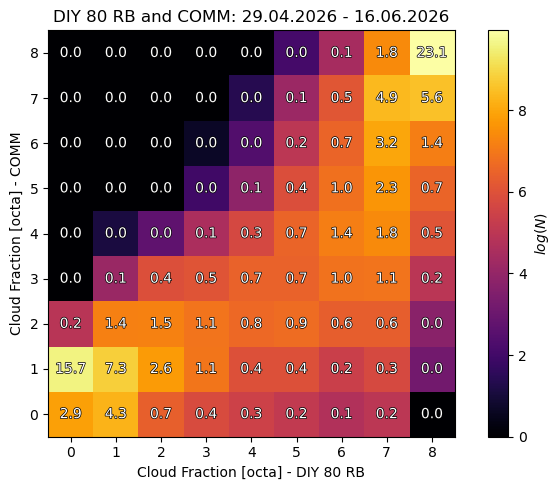

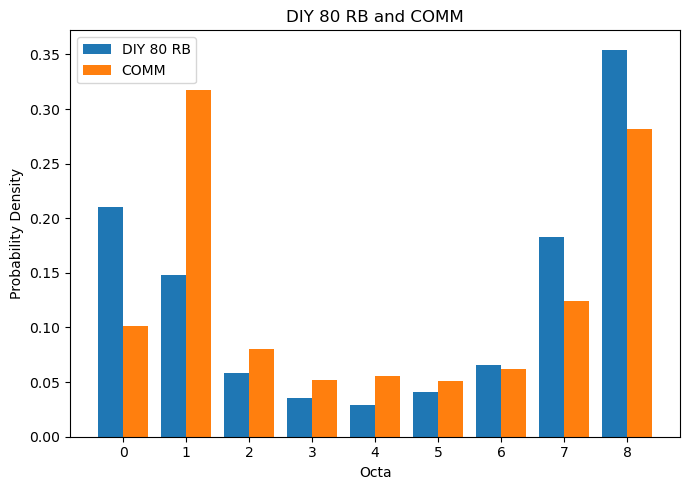

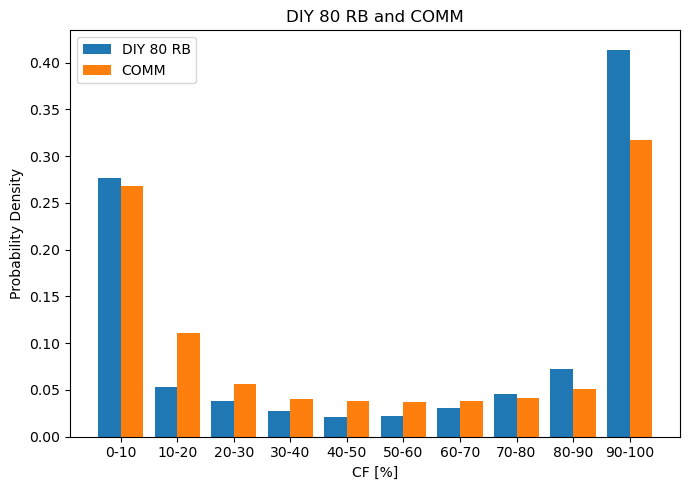

In [21]:
#32# COMPARISON: DIY ASI 80 (RB) - COMM

df_select = df_complete[["diy_80_rb", "comm"]]
df_select.dropna(inplace=True)

print(len(df_select))

nameroot = "compare_diy80rb_comm"

#######################################################################################################################################

plot_txy = ["DIY 80 RB and COMM: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - DIY 80 RB", "Cloud Fraction [%] - COMM"]

cplt.render_heatmap_frac(df_select["diy_80_rb"], df_select["comm"], plot_txy, nameroot+"_frac.png")

#######################################################################################################################################

plot_txy = ["DIY 80 RB and COMM: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [%] - DIY 80 RB", "Cloud Fraction [%] - COMM"]

cplt.render_heatmap_frac10(df_select["diy_80_rb"], df_select["comm"], plot_txy, nameroot+"_fr10.png")

#######################################################################################################################################

df_select_octa = df_select.copy()

df_select_octa["diy_80_rb"] = cpl.convert_frac_to_octa(df_select_octa["diy_80_rb"])
df_select_octa["comm"] = cpl.convert_frac_to_octa(df_select_octa["comm"])

plot_txy = ["DIY 80 RB and COMM: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "Cloud Fraction [octa] - DIY 80 RB", "Cloud Fraction [octa] - COMM"]

cplt.render_heatmap_octa(df_select_octa["diy_80_rb"], df_select_octa["comm"], plot_txy, nameroot+"_octa.png")

#######################################################################################################################################

hist_collector = [df_select_octa["diy_80_rb"], df_select_octa["comm"]]
label_collector = ["DIY 80 RB", "COMM"]

cplt.render_n_col_octa(hist_collector, label_collector, "DIY 80 RB and COMM", nameroot+"_cols.png")

#######################################################################################################################################

hist_collector = [df_select["diy_80_rb"], df_select["comm"]]
label_collector = ["DIY 80 RB", "COMM"]

cplt.render_n_col_frac(hist_collector, label_collector, "DIY 80 RB and COMM", nameroot+"_co10.png")

/home/sdoeding/analysis_scripts/libraries/compare_plots.py:17: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)
/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)
/home/sdoeding/analysis_scripts/libraries/compare_plots.py:17: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)
/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)
/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


RMSE [%]: 33.140067429986765
Exact: 49.8 % --- 1 octa: 68.4%
RMSE [octa]: 2.636121051684501
RMSE [%]: 31.867963530277546
Exact: 54.8 % --- 1 octa: 75.1%
RMSE [octa]: 2.523911620903131
Exact: 47.9 % --- 1 octa: 73.1%
RMSE [octa]: 2.5129534545898506


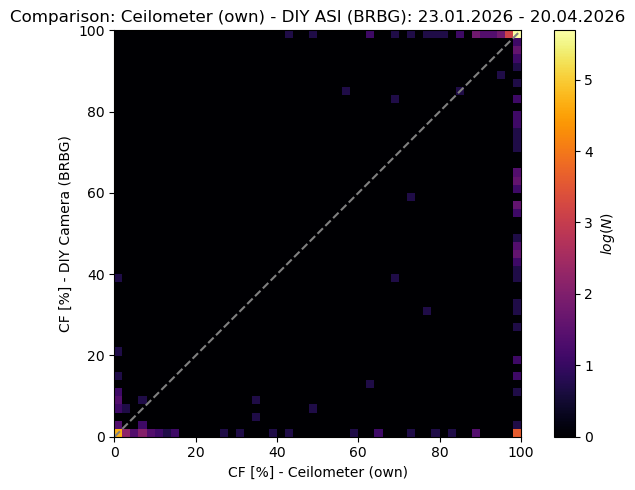

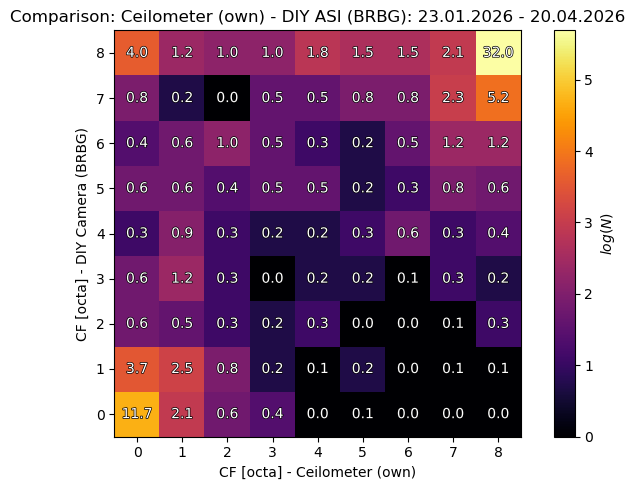

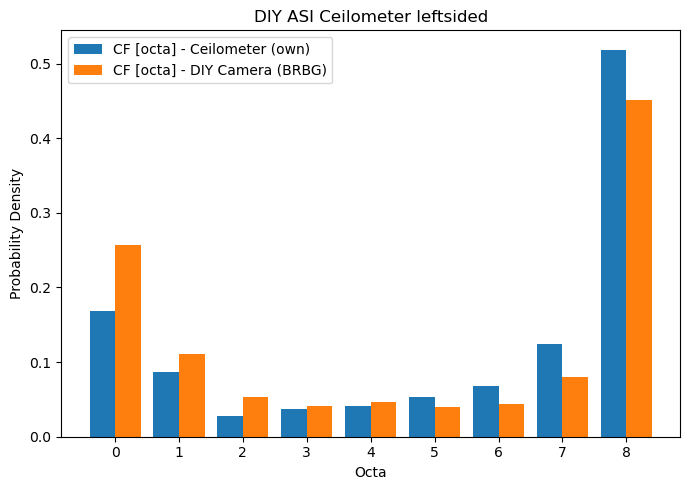

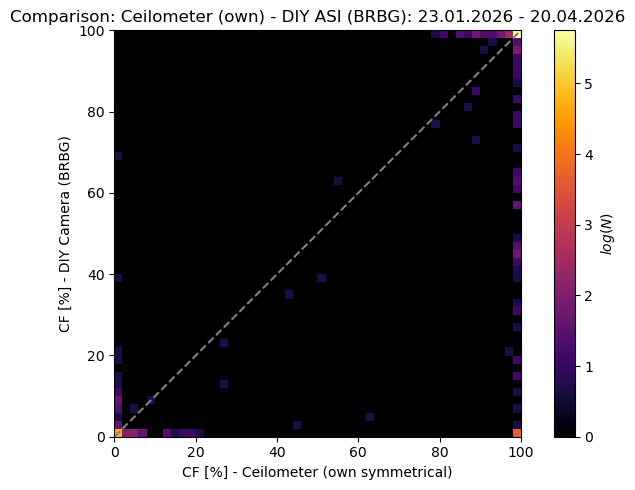

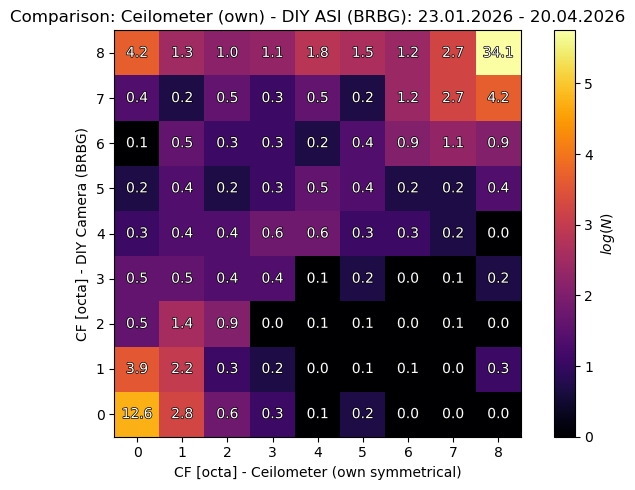

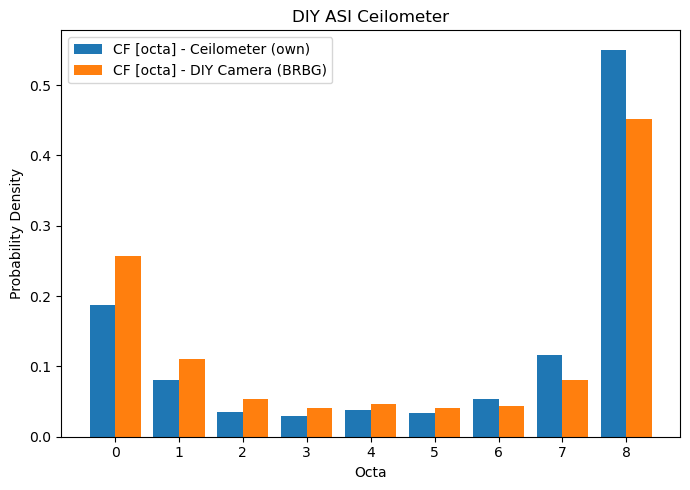

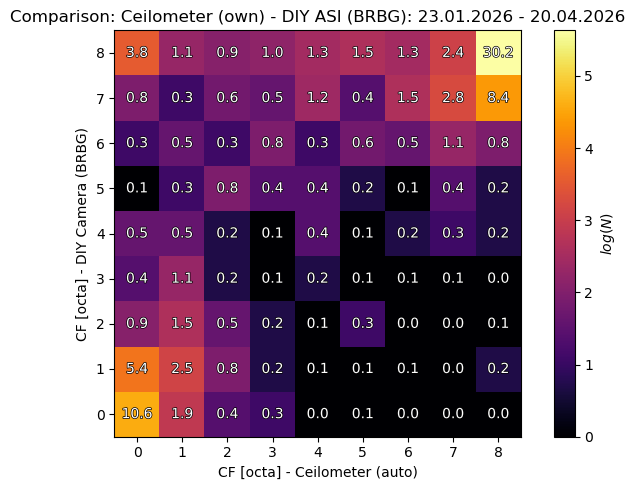

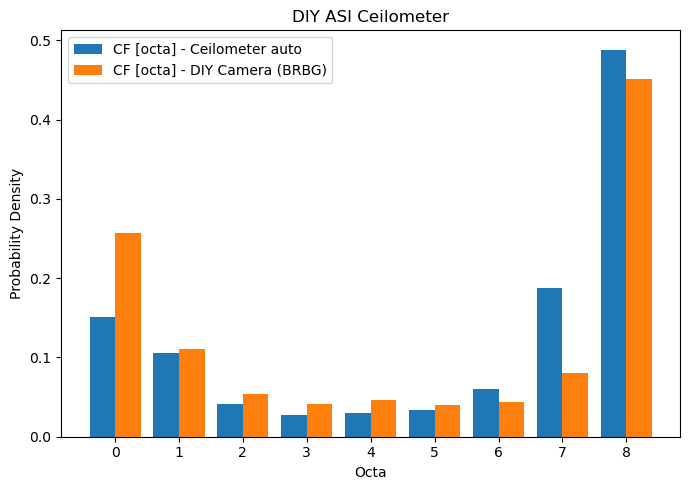

In [18]:
## COMPARISON AVERAGED: DIY ASI 05 (BRBG) - CEILO all

df_select = df_complete_10min[["ceilo_own_left", "diy_05_brbg"]].copy()
df_select.dropna(inplace=True)

nameroot = "compare_ceiloownleft_diy05brbg"

#######################################################################################################################################

plot_txy=["Comparison: Ceilometer (own) - DIY ASI (BRBG): {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
         "CF [%] - Ceilometer (own)", "CF [%] - DIY Camera (BRBG)"]

cplt.render_heatmap_frac(df_select["ceilo_own_left"], df_select["diy_05_brbg"], plot_txy,-1)

#######################################################################################################################################

df_select_octa = df_select

df_select_octa["diy_05_brbg"] = cpl.convert_frac_to_octa(df_select_octa["diy_05_brbg"])
df_select_octa["ceilo_own_left"] = cpl.convert_frac_to_octa(df_select_octa["ceilo_own_left"])

plot_txy = ["Comparison: Ceilometer (own) - DIY ASI (BRBG): {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "CF [octa] - Ceilometer (own)", "CF [octa] - DIY Camera (BRBG)"]

cplt.render_heatmap_octa(df_select_octa["diy_05_brbg"], df_select_octa["ceilo_own_left"], plot_txy, -1)

#######################################################################################################################################

hist_collector = [df_select_octa["ceilo_own_left"], df_select_octa["diy_05_brbg"]]
label_collector = ["CF [octa] - Ceilometer (own)", "CF [octa] - DIY Camera (BRBG)"]

cplt.render_n_col_octa(hist_collector, label_collector, "DIY ASI Ceilometer leftsided", -1)







## COMPARISON: DIY ASI 05 (BRBG) - CEILO symmetrical

df_select = df_complete_10min[["ceilo_own_symm", "diy_05_brbg"]]
df_select.dropna(inplace=True)

nameroot = "compare_ceiloownsym_diy05brbg"

#######################################################################################################################################

plot_txy=["Comparison: Ceilometer (own) - DIY ASI (BRBG): {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
         "CF [%] - Ceilometer (own symmetrical)", "CF [%] - DIY Camera (BRBG)"]

cplt.render_heatmap_frac(df_select["ceilo_own_symm"], df_select["diy_05_brbg"], plot_txy, -1)

#######################################################################################################################################

df_select_octa = df_select

df_select_octa["diy_05_brbg"] = cpl.convert_frac_to_octa(df_select["diy_05_brbg"])
df_select_octa["ceilo_own_symm"] = cpl.convert_frac_to_octa(df_select["ceilo_own_symm"])

plot_txy = ["Comparison: Ceilometer (own) - DIY ASI (BRBG): {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "CF [octa] - Ceilometer (own symmetrical)", "CF [octa] - DIY Camera (BRBG)"]

cplt.render_heatmap_octa(df_select_octa["diy_05_brbg"], df_select_octa["ceilo_own_symm"], plot_txy, -1)

#######################################################################################################################################

hist_collector = [df_select_octa["ceilo_own_symm"], df_select_octa["diy_05_brbg"]]
label_collector = ["CF [octa] - Ceilometer (own)", "CF [octa] - DIY Camera (BRBG)"]

cplt.render_n_col_octa(hist_collector, label_collector, "DIY ASI Ceilometer", -1)







## COMPARISON: DIY ASI 05 (BRBG) - CEILO auto

df_select = df_complete_10min[["ceilo_auto", "diy_05_brbg"]]
df_select.dropna(inplace=True)

nameroot = "compare_ceiloauto_diy05brbg"

#######################################################################################################################################

df_select_octa = df_select

df_select_octa["diy_05_brbg"] = cpl.convert_frac_to_octa(df_select["diy_05_brbg"])
df_select_octa["ceilo_auto"] = cpl.convert_frac_to_octa(df_select["ceilo_auto"])

plot_txy = ["Comparison: Ceilometer (own) - DIY ASI (BRBG): {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "CF [octa] - Ceilometer (auto)", "CF [octa] - DIY Camera (BRBG)"]

cplt.render_heatmap_octa(df_select_octa["diy_05_brbg"], df_select_octa["ceilo_auto"], plot_txy, -1)

#######################################################################################################################################

hist_collector = [df_select_octa["ceilo_auto"], df_select_octa["diy_05_brbg"]]
label_collector = ["CF [octa] - Ceilometer auto", "CF [octa] - DIY Camera (BRBG)"]

cplt.render_n_col_octa(hist_collector, label_collector, "DIY ASI Ceilometer", -1)

/home/sdoeding/analysis_scripts/libraries/compare_plots.py:91: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(plot_data)


Exact: 70.6 % --- 1 octa: 86.1%
RMSE [octa]: 1.1828846627714524
Exact: 70.8 % --- 1 octa: 92.2%
RMSE [octa]: 0.8275085719979722
Exact: 67.8 % --- 1 octa: 91.6%
RMSE [octa]: 0.8610002256549226


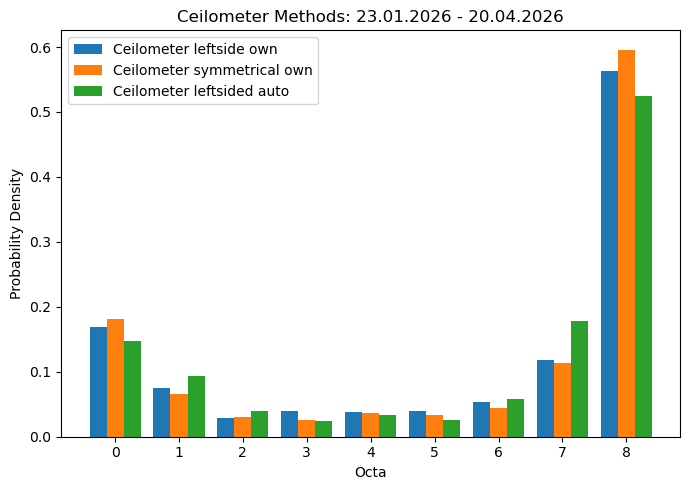

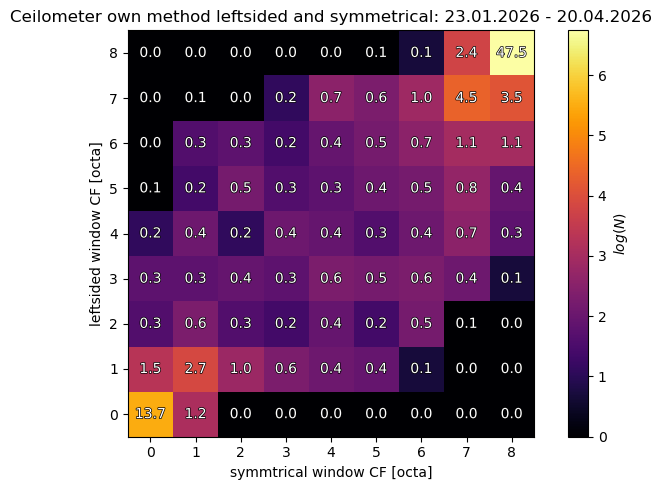

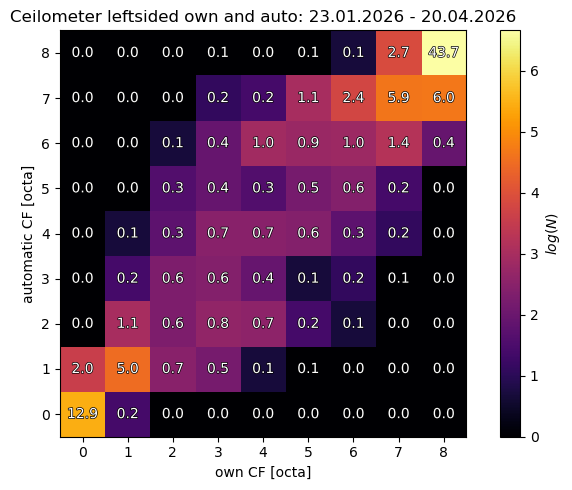

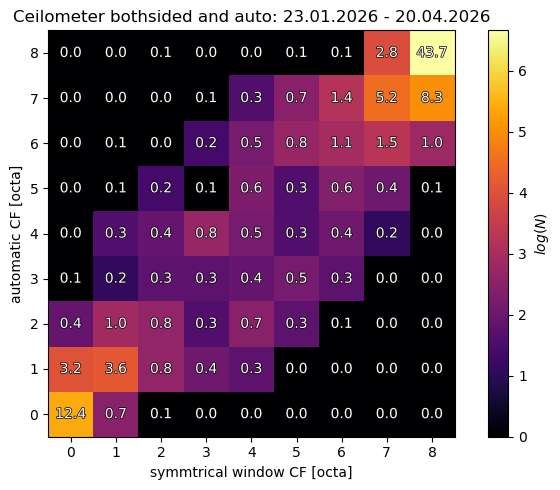

In [19]:
## COMPARISON AVERAGED: Ceilometer all methods

df_select = df_complete_10min[["ceilo_own_left", "ceilo_own_symm", "ceilo_auto"]]
df_select.dropna(inplace=True)

df_select_octa = df_select.copy()

df_select_octa["ceilo_own_left"] = cpl.convert_frac_to_octa(df_select_octa["ceilo_own_left"])
df_select_octa["ceilo_own_symm"] = cpl.convert_frac_to_octa(df_select_octa["ceilo_own_symm"])
df_select_octa["ceilo_auto"] = cpl.convert_frac_to_octa(df_select_octa["ceilo_auto"])

####################################

hist_collector = [df_select_octa["ceilo_own_left"], df_select_octa["ceilo_own_symm"], df_select_octa["ceilo_auto"]]
label_collector = ["Ceilometer leftside own","Ceilometer symmetrical own","Ceilometer leftsided auto"]

cplt.render_n_col_octa(hist_collector, label_collector,"Ceilometer Methods: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
                  "compare_ceilo_all_cols.png")

####################################

plot_txy = ["Ceilometer own method leftsided and symmetrical: {0} - {1}".format(df_select.index[0].strftime("%d.%m.%Y"),df_select.index[-1].strftime("%d.%m.%Y")),
           "symmtrical window CF [octa]", "leftsided window CF [octa]"]

cplt.render_heatmap_octa(df_select_octa["ceilo_own_symm"], df_select_octa["ceilo_own_left"], plot_txy, "compare_ceiloownsymm_ceiloownleft")

####################################

plot_txy = ["Ceilometer leftsided own and auto: {0} - {1}".format(data_cei_res.index[0].strftime("%d.%m.%Y"),data_cei_res.index[-1].strftime("%d.%m.%Y")),
           "own CF [octa]", "automatic CF [octa]"]

cplt.render_heatmap_octa(df_select_octa["ceilo_own_left"], df_select_octa["ceilo_auto"], plot_txy, -1)

####################################

plot_txy = ["Ceilometer bothsided and auto: {0} - {1}".format(data_cei_res.index[0].strftime("%d.%m.%Y"),data_cei_res.index[-1].strftime("%d.%m.%Y")),
           "symmtrical window CF [octa]", "automatic CF [octa]"]

cplt.render_heatmap_octa(df_select_octa["ceilo_own_symm"], df_select_octa["ceilo_auto"], plot_txy, -1)


<>:49: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:49: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_3953171/2384226824.py:49: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.ylabel("$\Delta CF$ [%]")
/tmp/ipykernel_3953171/2384226824.py:13: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(heatmap.T)
/tmp/ipykernel_3953171/2384226824.py:41: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(heatmap.T)


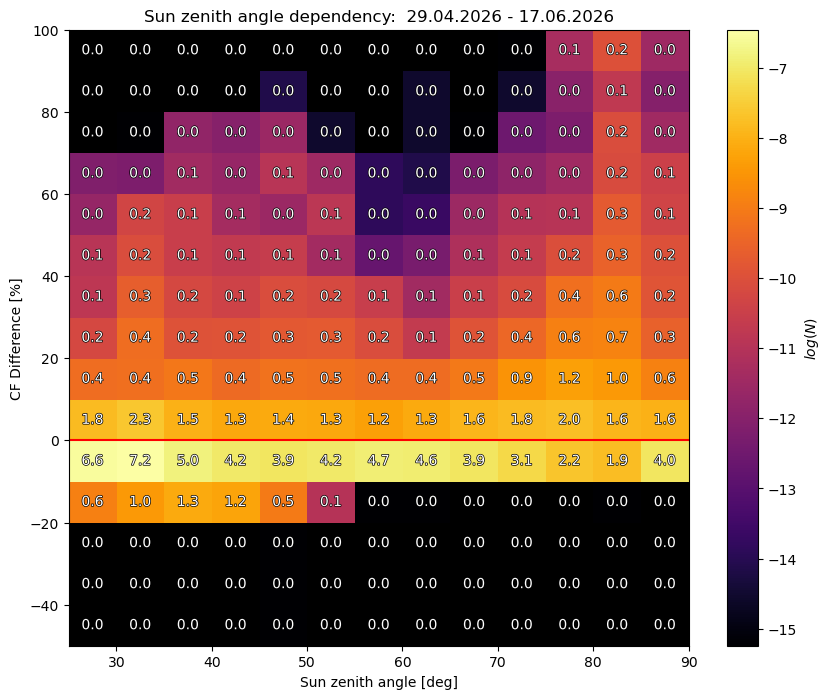

<Figure size 640x480 with 0 Axes>

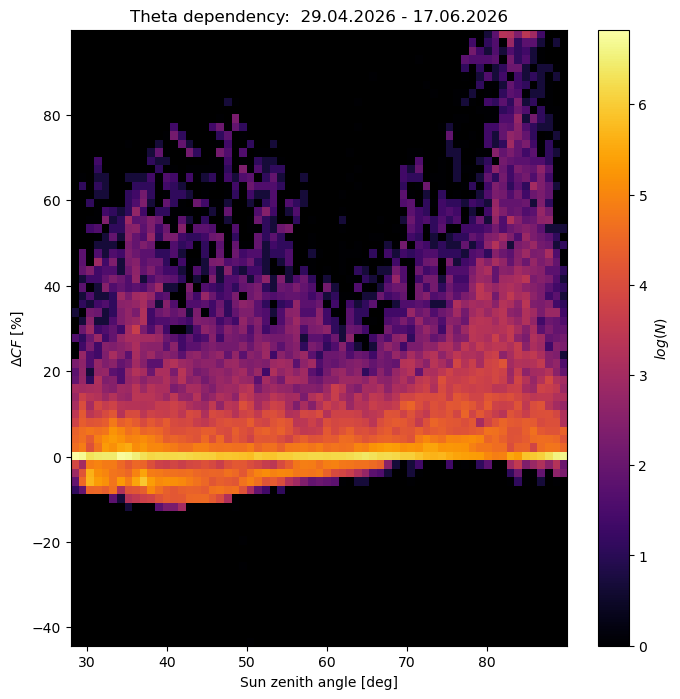

In [27]:
## ZENITH ANGLE INFLUENCE: DIY ASI 65 (BRBG) - COMM

df_select = df_complete[["diy_65_brbg", "comm", "Sun_Elevation"]]
df_select.dropna(inplace=True)

cf_diff = df_select["diy_65_brbg"] - df_select["comm"]

heatmap, xedges, yedges = np.histogram2d(90 - df_select["Sun_Elevation"], cf_diff, bins=(13,15), density=True)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
percent = heatmap / heatmap.sum() * 100

plot_data = heatmap.T
plot_data = np.log(heatmap.T)
plot_data = np.where(np.isfinite(plot_data), plot_data, np.nan)

plt.figure(figsize=(10,8))
plt.imshow(plot_data, extent=[25,90,-50,100], origin="lower", cmap="inferno", aspect="auto")
plt.colorbar(label="$log(N)$")
#plt.ylim(0,100)
#plt.xlim(20,sun_filter)
plt.title("Sun zenith angle dependency:  {0} - {1}".format(dt.datetime(2026,4,29).strftime("%d.%m.%Y"),dt.datetime(2026,6,17).strftime("%d.%m.%Y")))
plt.xlabel("Sun zenith angle [deg]")
plt.ylabel("CF Difference [%]")
plt.plot([25,90], [0,0], color="red")

ax = plt.gca()
for i in range(0,13):
    for j in range(0,15):
        t = ax.text(i*5+25+2.5, j*10-50+5,np.round(percent[i,j],1), ha="center", va="center", color="white")
        t.set_path_effects([pe.Stroke(linewidth=1, foreground="black"), pe.Normal()])

ax.set_facecolor("black")


plt.figure()

heatmap, xedges, yedges = np.histogram2d(90 - df_select["Sun_Elevation"], cf_diff, bins=(65,73))
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plot_data = heatmap.T
plot_data = np.log(heatmap.T)
plot_data = np.where(np.isfinite(plot_data), plot_data, np.min(plot_data))

plt.figure(figsize=(8,8))
plt.imshow(plot_data, extent=extent, origin="lower", cmap="inferno", aspect="auto")
plt.colorbar(label="$log(N)$")
plt.title("Theta dependency:  {0} - {1}".format(dt.datetime(2026,4,29).strftime("%d.%m.%Y"),dt.datetime(2026,6,17).strftime("%d.%m.%Y")))
plt.xlabel("Sun zenith angle [deg]")
plt.ylabel("$\Delta CF$ [%]")

plt.gca().set_facecolor("black")

plt.savefig("compare_cfdiff_theta.png")

/tmp/ipykernel_1293323/219788712.py:13: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(heatmap.T)
/tmp/ipykernel_1293323/219788712.py:41: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(heatmap.T)


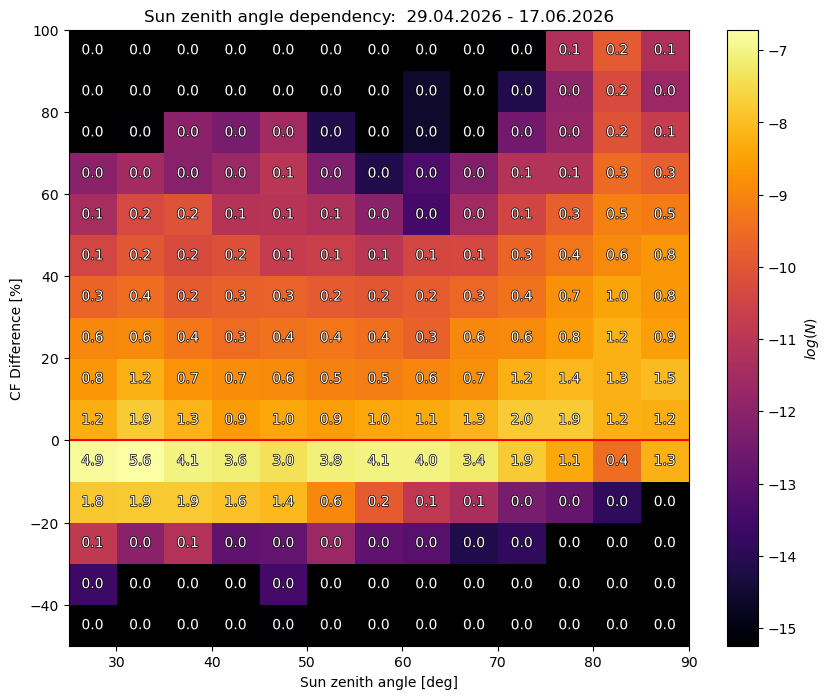

<Figure size 640x480 with 0 Axes>

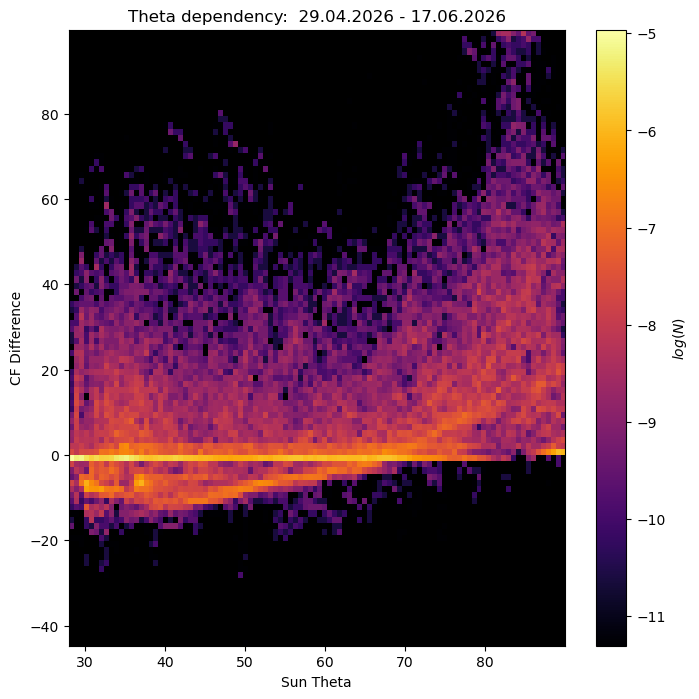

In [22]:
## ZENITH ANGLE INFLUENCE: DIY ASI 80 (BRBG) - COMM

df_select = df_complete[["diy_80_brbg", "comm", "Sun_Elevation"]]
df_select.dropna(inplace=True)

cf_diff = df_select["diy_80_brbg"] - df_select["comm"]

heatmap, xedges, yedges = np.histogram2d(90 - df_select["Sun_Elevation"], cf_diff, bins=(13,15), density=True)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
percent = heatmap / heatmap.sum() * 100

plot_data = heatmap.T
plot_data = np.log(heatmap.T)
plot_data = np.where(np.isfinite(plot_data), plot_data, np.nan)

plt.figure(figsize=(10,8))
plt.imshow(plot_data, extent=[25,90,-50,100], origin="lower", cmap="inferno", aspect="auto")
plt.colorbar(label="$log(N)$")
#plt.ylim(0,100)
#plt.xlim(20,sun_filter)
plt.title("Sun zenith angle dependency:  {0} - {1}".format(dt.datetime(2026,4,29).strftime("%d.%m.%Y"),dt.datetime(2026,6,17).strftime("%d.%m.%Y")))
plt.xlabel("Sun zenith angle [deg]")
plt.ylabel("CF Difference [%]")
plt.plot([25,90], [0,0], color="red")

ax = plt.gca()
for i in range(0,13):
    for j in range(0,15):
        t = ax.text(i*5+25+2.5, j*10-50+5,np.round(percent[i,j],1), ha="center", va="center", color="white")
        t.set_path_effects([pe.Stroke(linewidth=1, foreground="black"), pe.Normal()])

ax.set_facecolor("black")


plt.figure()

heatmap, xedges, yedges = np.histogram2d(90 - df_select["Sun_Elevation"], cf_diff, bins=100, density=True)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plot_data = heatmap.T
plot_data = np.log(heatmap.T)
plot_data = np.where(np.isfinite(plot_data), plot_data, np.min(plot_data))

plt.figure(figsize=(8,8))
plt.imshow(plot_data, extent=extent, origin="lower", cmap="inferno", aspect="auto")
plt.colorbar(label="$log(N)$")
plt.title("Theta dependency:  {0} - {1}".format(dt.datetime(2026,4,29).strftime("%d.%m.%Y"),dt.datetime(2026,6,17).strftime("%d.%m.%Y")))
plt.xlabel("Sun Theta")
plt.ylabel("CF Difference")

plt.gca().set_facecolor("black")

plt.savefig("compare_cfdiff_theta.png")

<>:49: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:49: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_928045/1780560429.py:49: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.ylabel("$\Delta CF$ [%]")
/tmp/ipykernel_928045/1780560429.py:13: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(heatmap.T)
/tmp/ipykernel_928045/1780560429.py:41: RuntimeWarning: divide by zero encountered in log
  plot_data = np.log(heatmap.T)


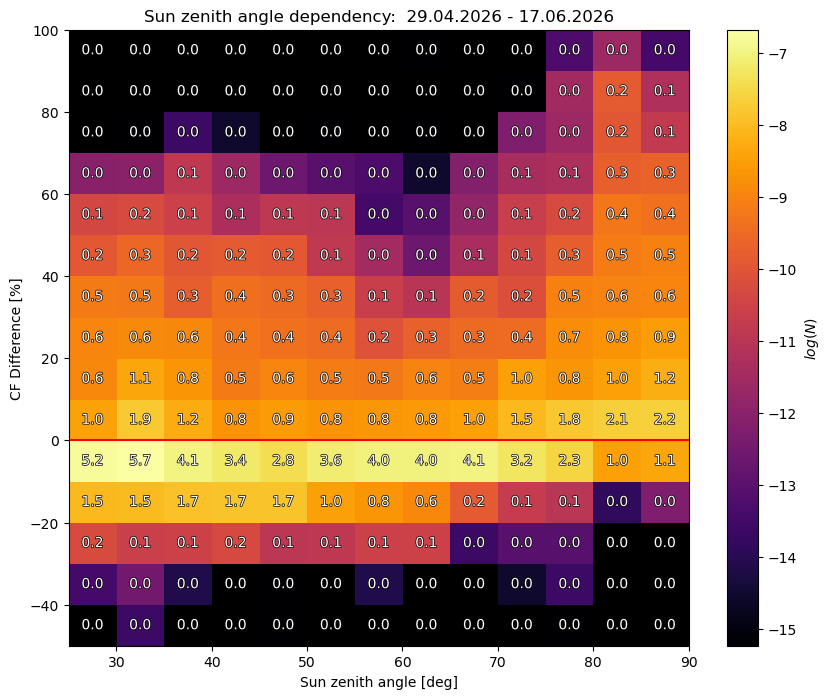

<Figure size 640x480 with 0 Axes>

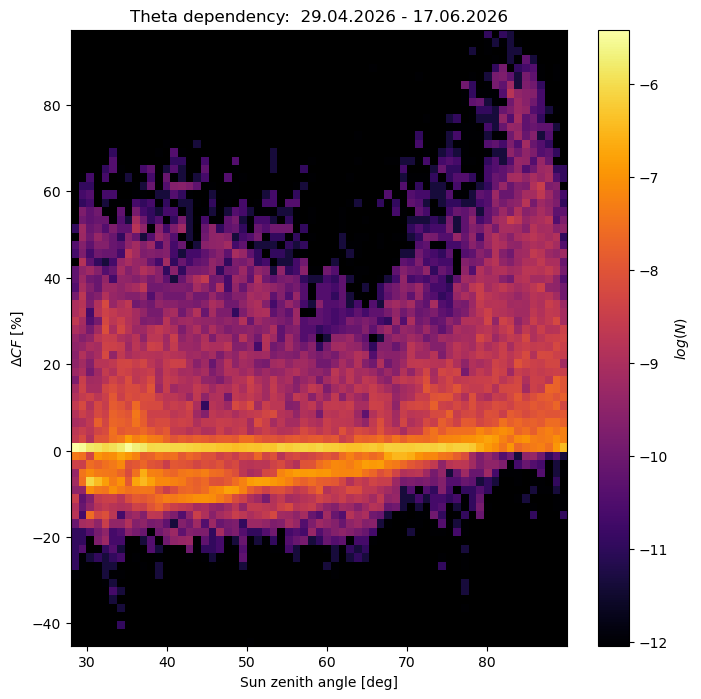

In [11]:
## ZENITH ANGLE INFLUENCE: DIY ASI 80 (RB) - COMM

df_select = df_complete[["diy_80_rb", "comm", "Sun_Elevation"]]
df_select.dropna(inplace=True)

cf_diff = df_select["diy_80_rb"] - df_select["comm"]

heatmap, xedges, yedges = np.histogram2d(90 - df_select["Sun_Elevation"], cf_diff, bins=(13,15), density=True)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
percent = heatmap / heatmap.sum() * 100

plot_data = heatmap.T
plot_data = np.log(heatmap.T)
plot_data = np.where(np.isfinite(plot_data), plot_data, np.nan)

plt.figure(figsize=(10,8))
plt.imshow(plot_data, extent=[25,90,-50,100], origin="lower", cmap="inferno", aspect="auto")
plt.colorbar(label="$log(N)$")
#plt.ylim(0,100)
#plt.xlim(20,sun_filter)
plt.title("Sun zenith angle dependency:  {0} - {1}".format(dt.datetime(2026,4,29).strftime("%d.%m.%Y"),dt.datetime(2026,6,17).strftime("%d.%m.%Y")))
plt.xlabel("Sun zenith angle [deg]")
plt.ylabel("CF Difference [%]")
plt.plot([25,90], [0,0], color="red")

ax = plt.gca()
for i in range(0,13):
    for j in range(0,15):
        t = ax.text(i*5+25+2.5, j*10-50+5,np.round(percent[i,j],1), ha="center", va="center", color="white")
        t.set_path_effects([pe.Stroke(linewidth=1, foreground="black"), pe.Normal()])

ax.set_facecolor("black")


plt.figure()

heatmap, xedges, yedges = np.histogram2d(90 - df_select["Sun_Elevation"], cf_diff, bins=(65,73), density=True)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plot_data = heatmap.T
plot_data = np.log(heatmap.T)
plot_data = np.where(np.isfinite(plot_data), plot_data, np.min(plot_data))

plt.figure(figsize=(8,8))
plt.imshow(plot_data, extent=extent, origin="lower", cmap="inferno", aspect="auto")
plt.colorbar(label="$log(N)$")
plt.title("Theta dependency:  {0} - {1}".format(dt.datetime(2026,4,29).strftime("%d.%m.%Y"),dt.datetime(2026,6,17).strftime("%d.%m.%Y")))
plt.xlabel("Sun zenith angle [deg]")
plt.ylabel("$\Delta CF$ [%]")

plt.gca().set_facecolor("black")

In [12]:
df_small = df_complete.loc["2026-05-01 12:00:00"]
df_small

ceilo_auto           NaN
ceilo_own_left       NaN
ceilo_own_symm       NaN
int_time             NaN
comm               8.000
Sun_Azimuth       20.830
Sun_Elevation     52.170
diy_05_rb          0.000
diy_05_brbg        0.075
diy_65_rb          0.140
diy_65_brbg        1.326
diy_80_rb          0.064
diy_80_brbg        0.280
Name: 2026-05-01 12:00:00, dtype: float64